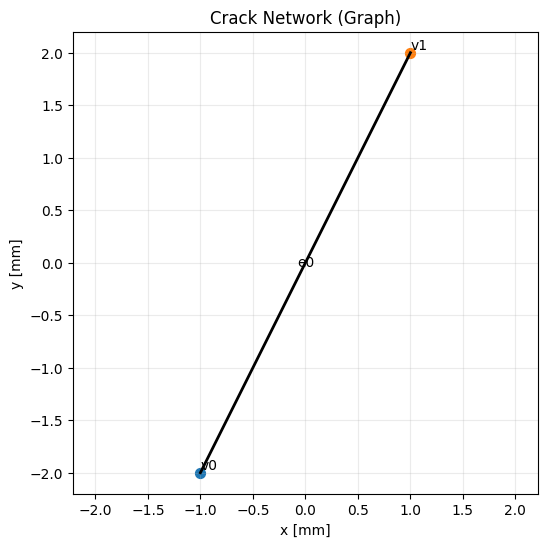

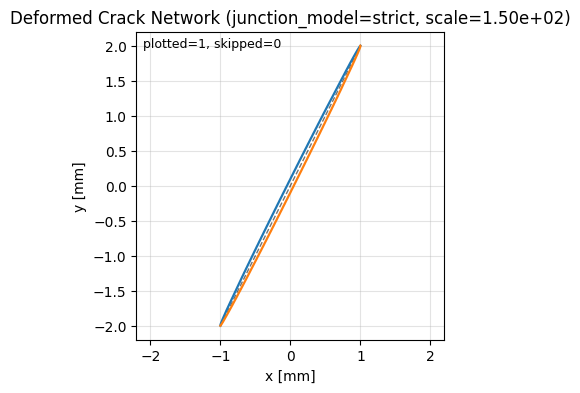

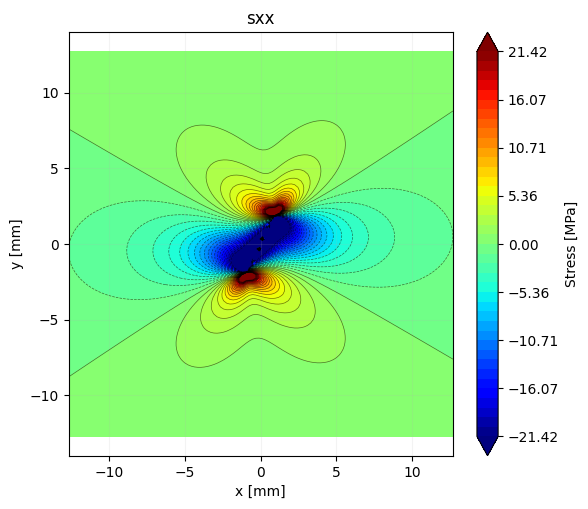

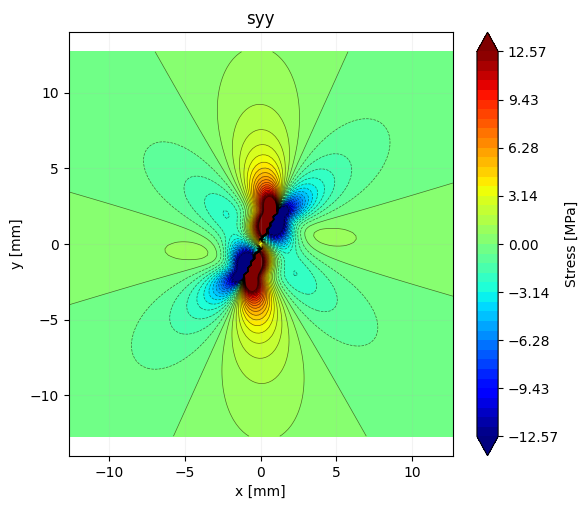

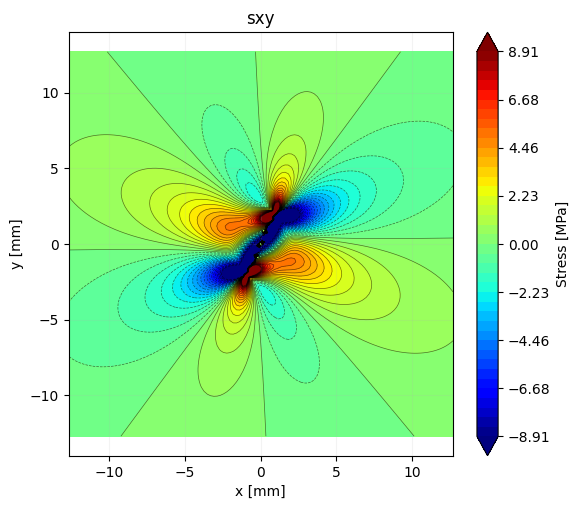

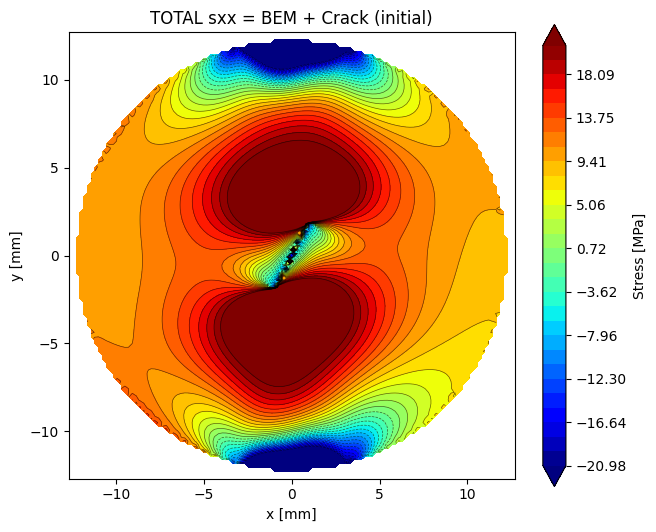

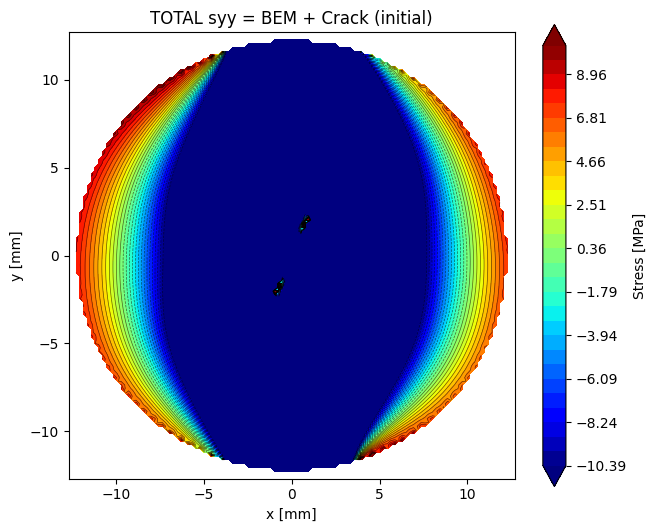

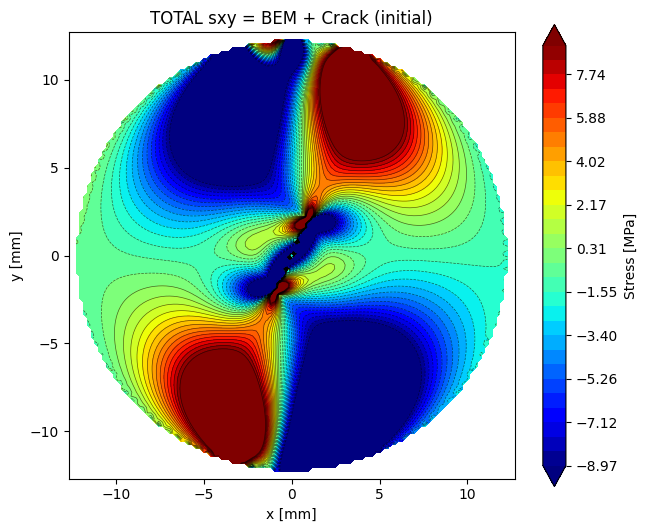

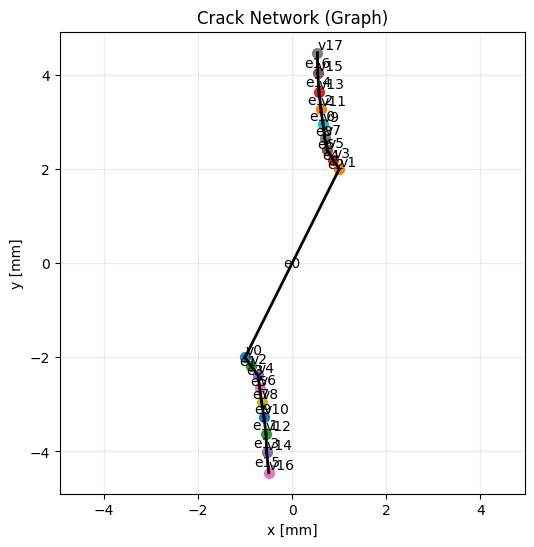

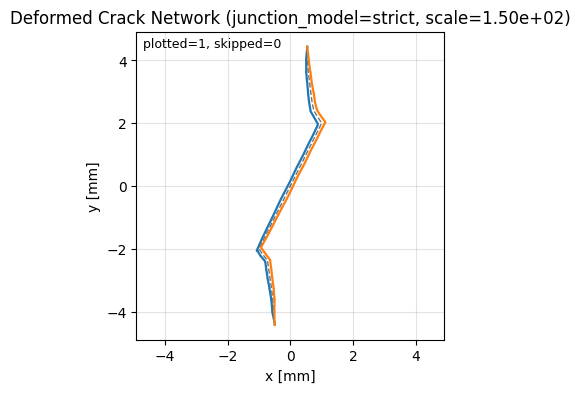

✓ Loaded network: 18 vertices, 17 edges


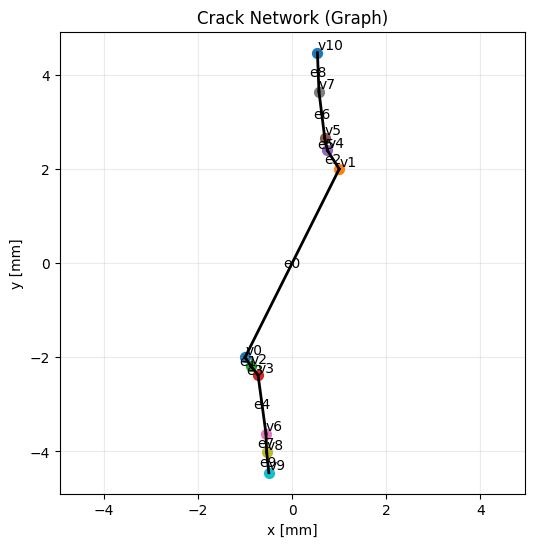

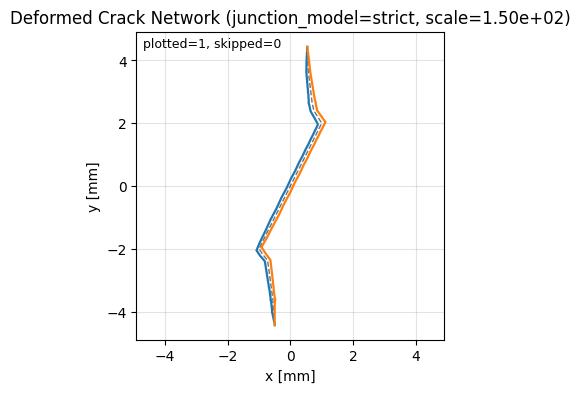

[coupling] UPDATE cycle_01_post_simplify: mismatch=inf, tip_dist=8.194e-03, tip_thr=1.267e-03, relax=1.00


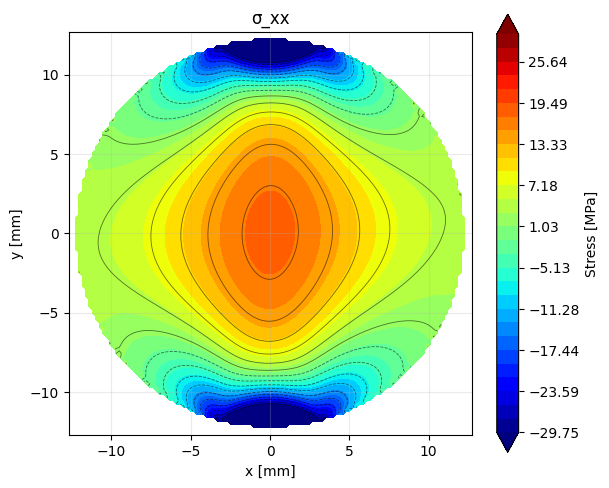

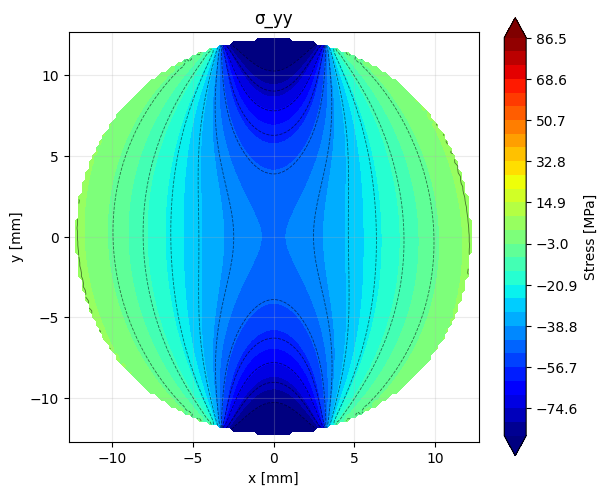

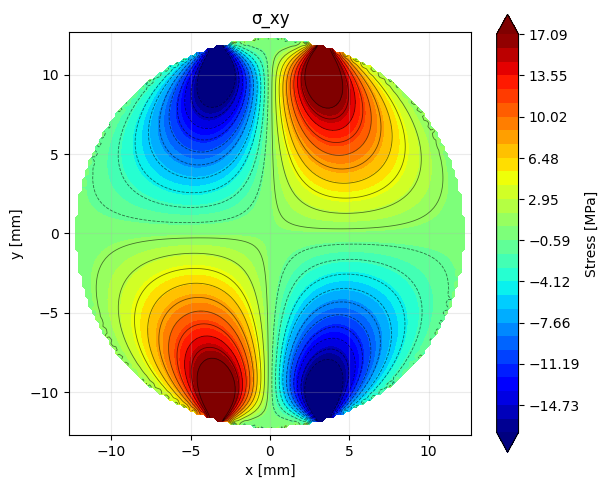

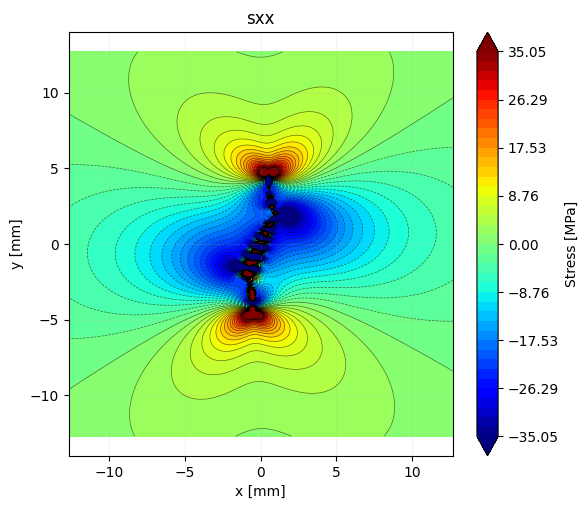

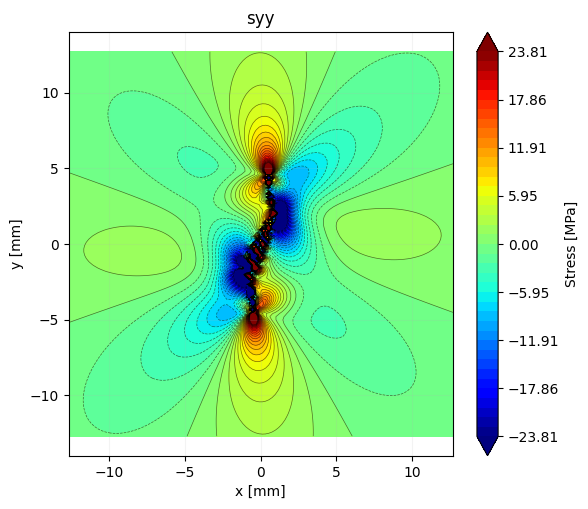

...

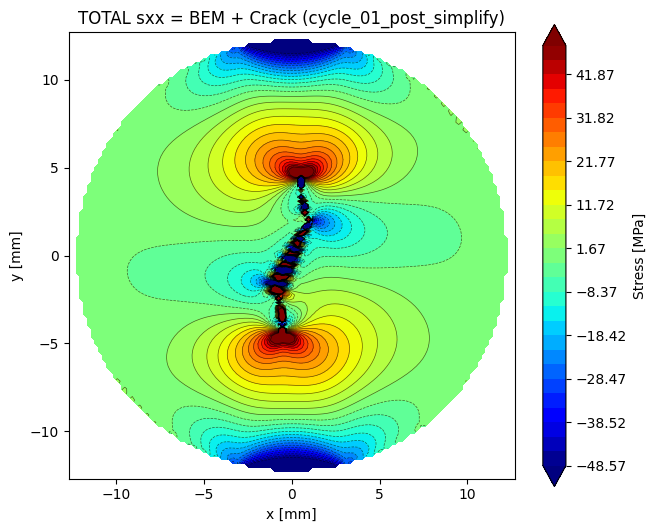

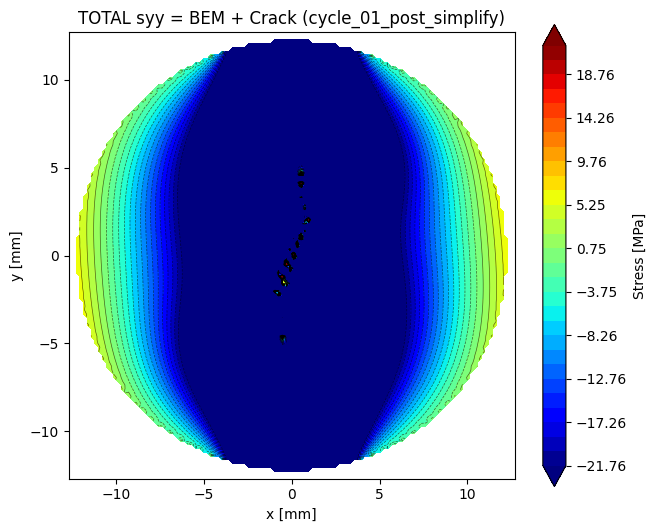

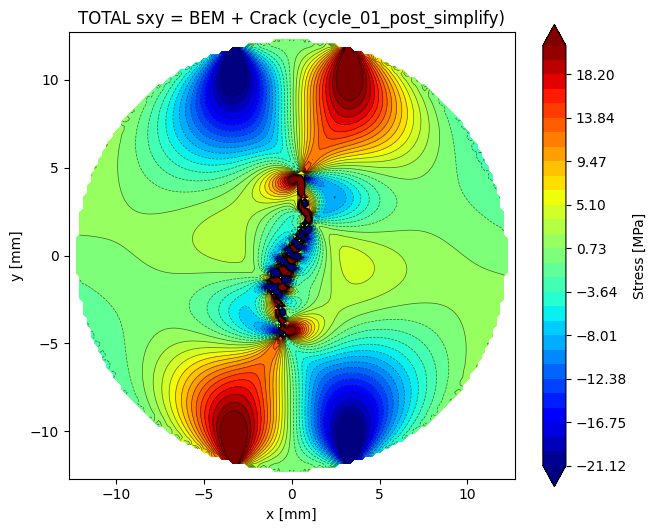

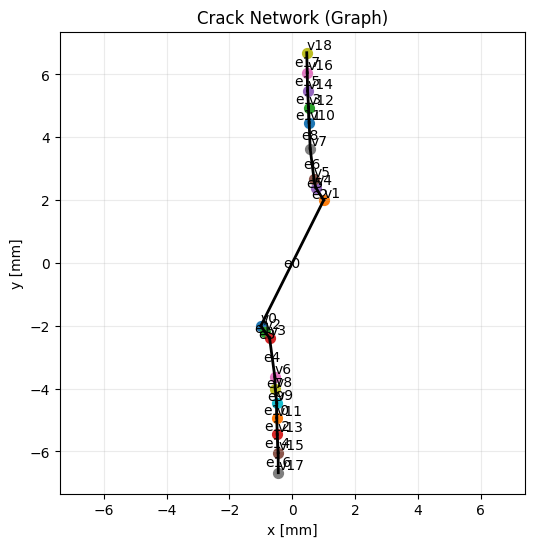

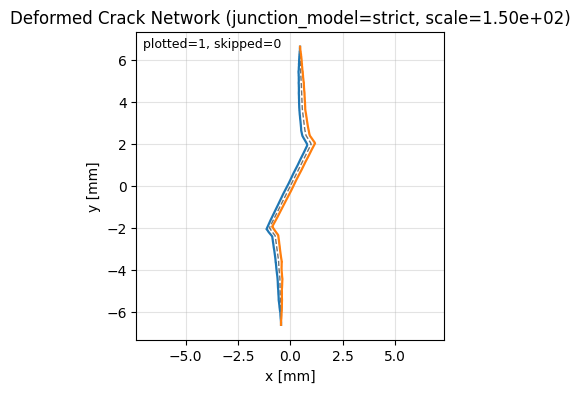

✓ Loaded network: 19 vertices, 18 edges


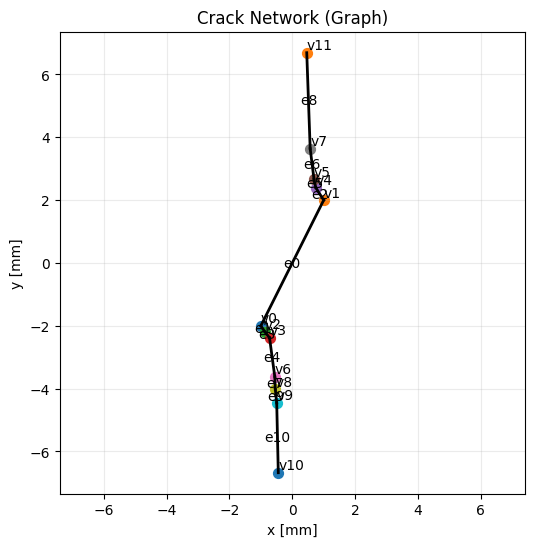

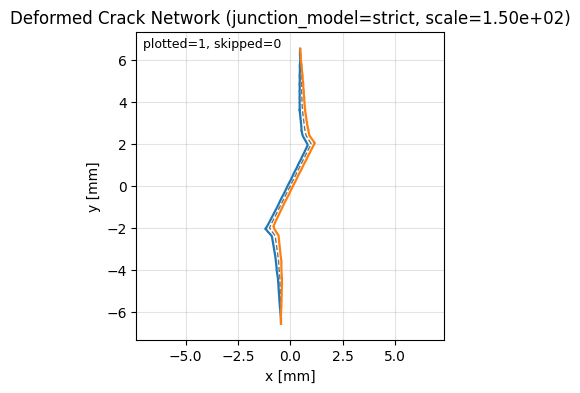

[coupling] UPDATE cycle_02_post_simplify: mismatch=9.521e-02, tip_dist=5.988e-03, tip_thr=5.280e-03, relax=1.00


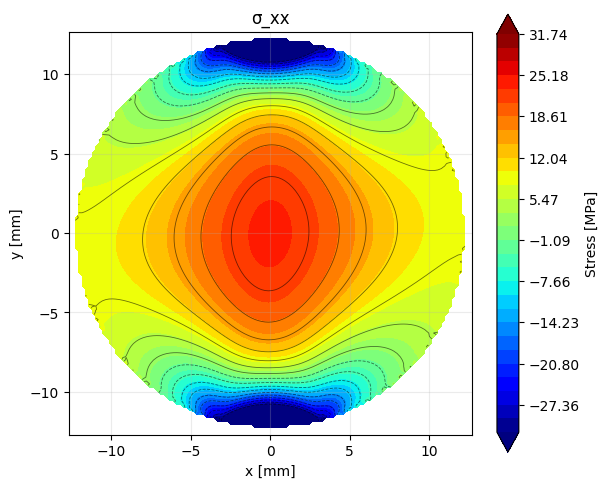

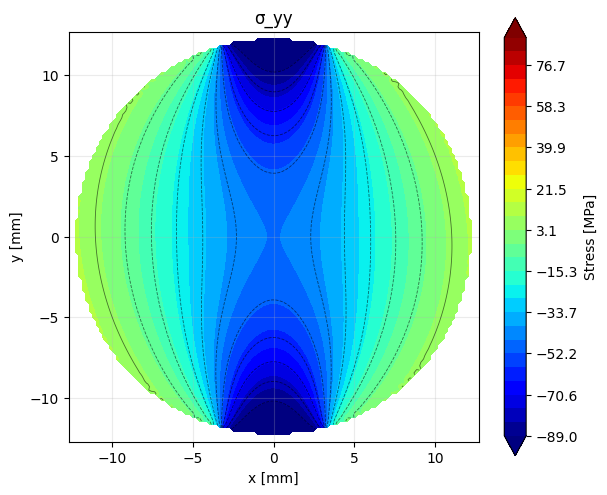

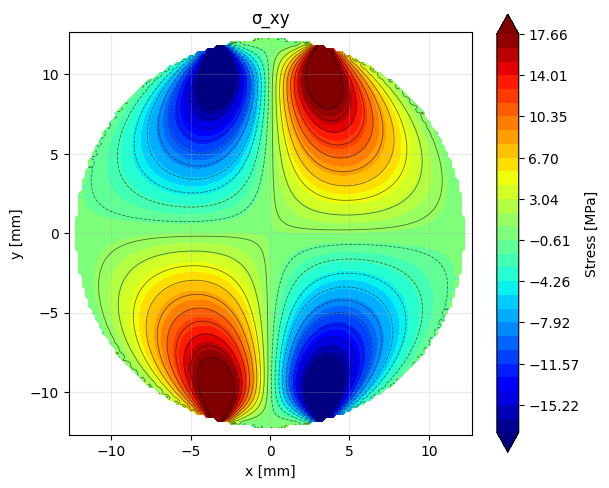

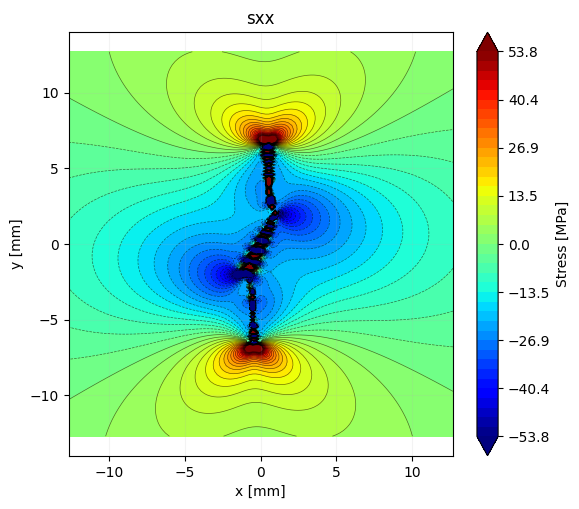

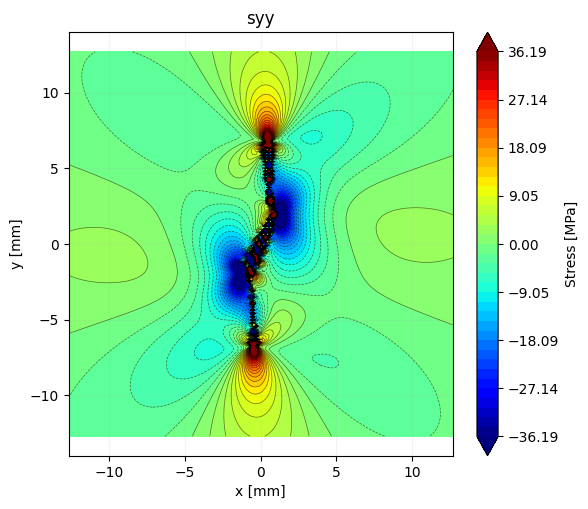

...

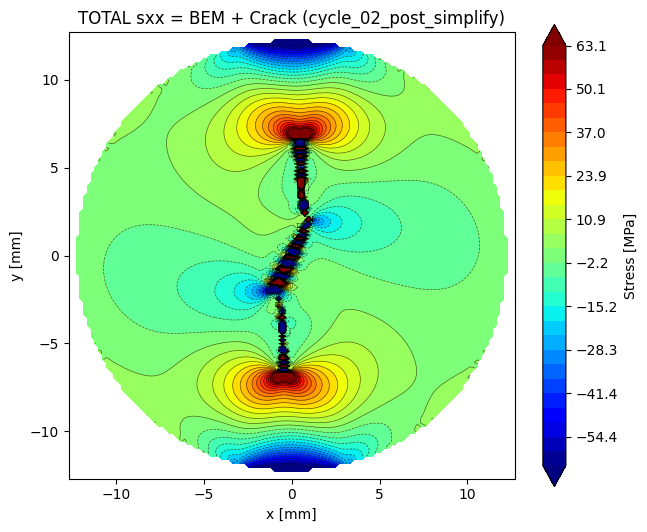

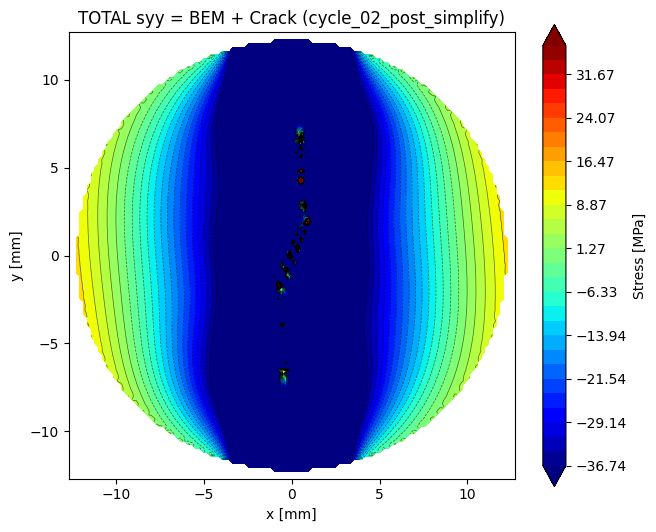

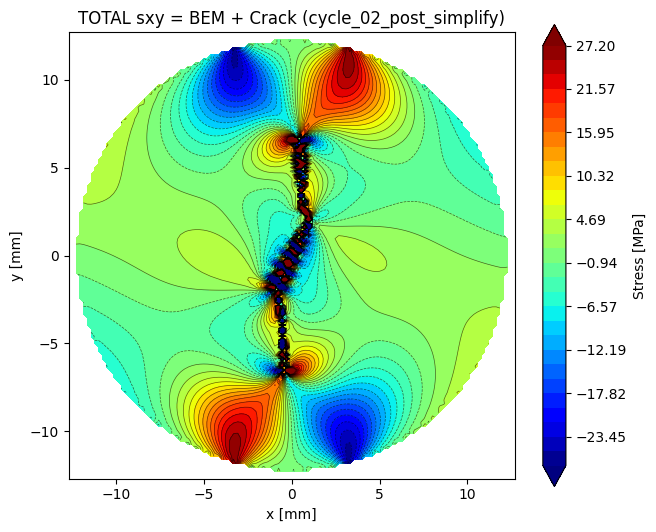

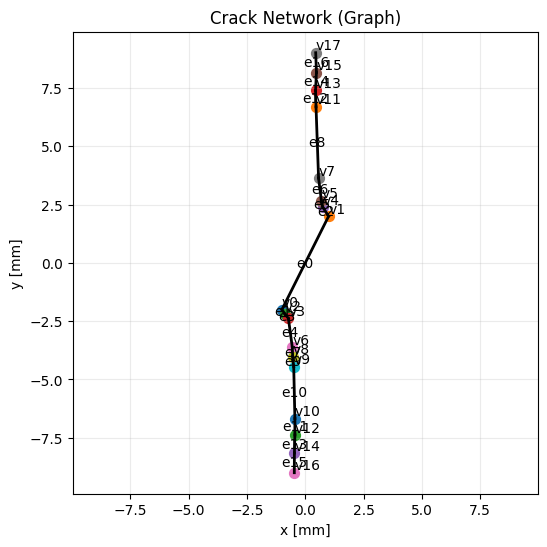

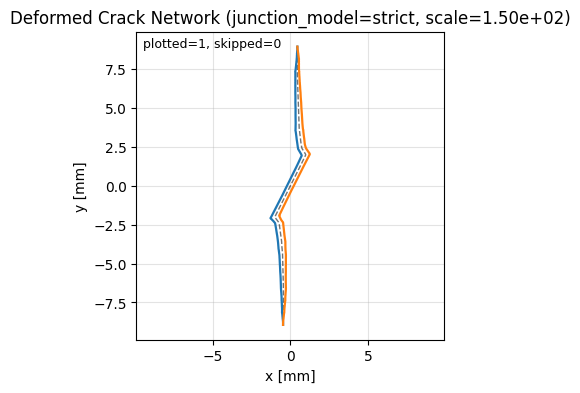

✓ Loaded network: 18 vertices, 17 edges


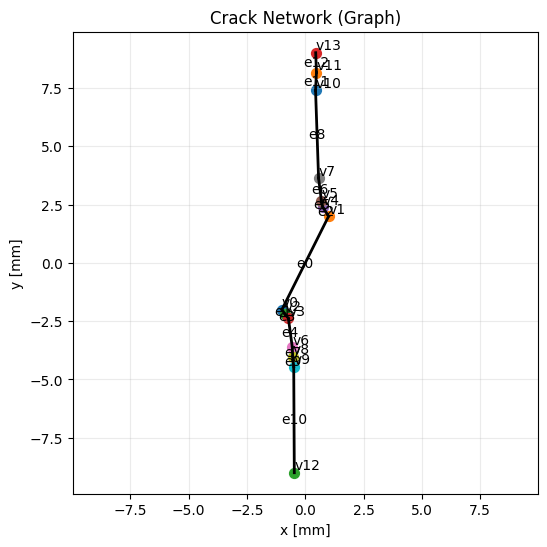

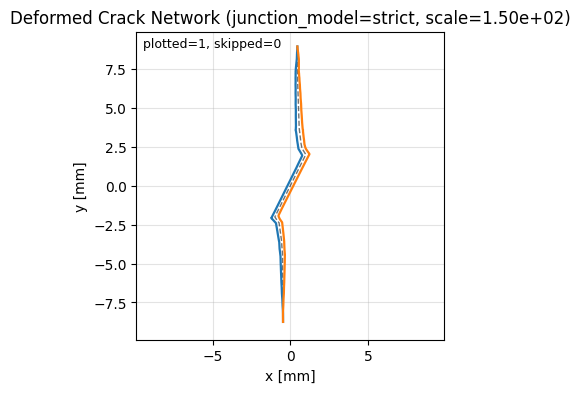

[coupling] UPDATE cycle_03_post_simplify: mismatch=9.632e-02, tip_dist=3.680e-03, tip_thr=5.395e-03, relax=1.00


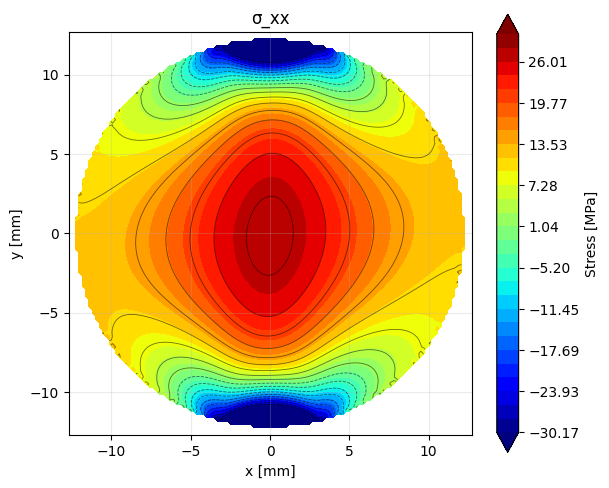

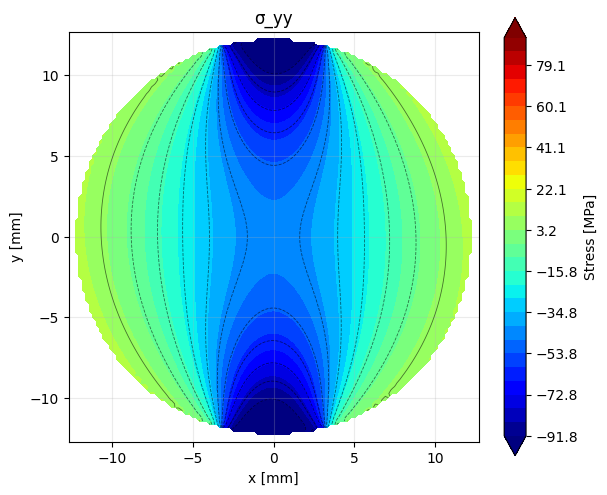

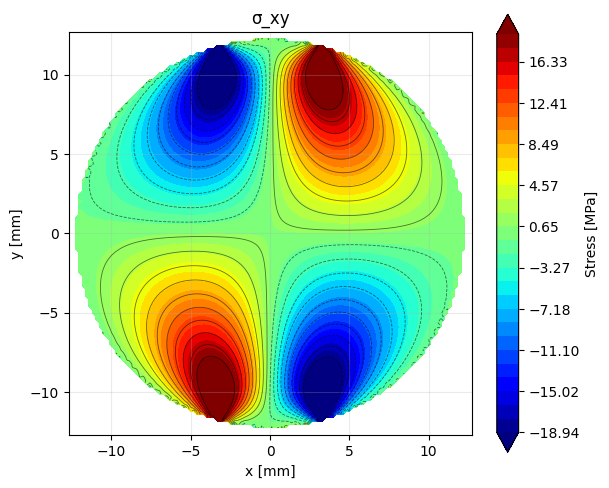

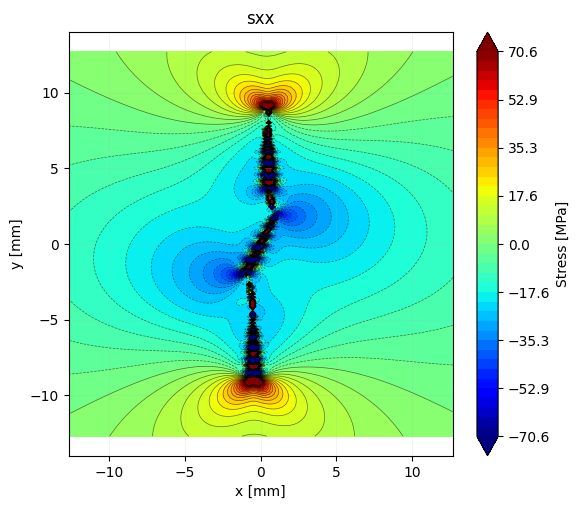

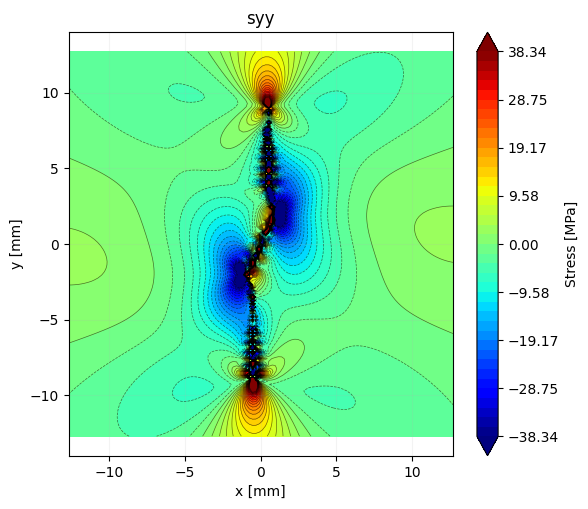

...

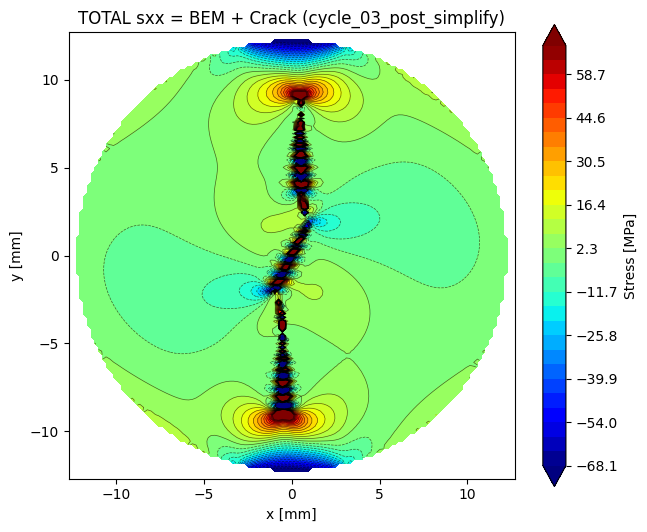

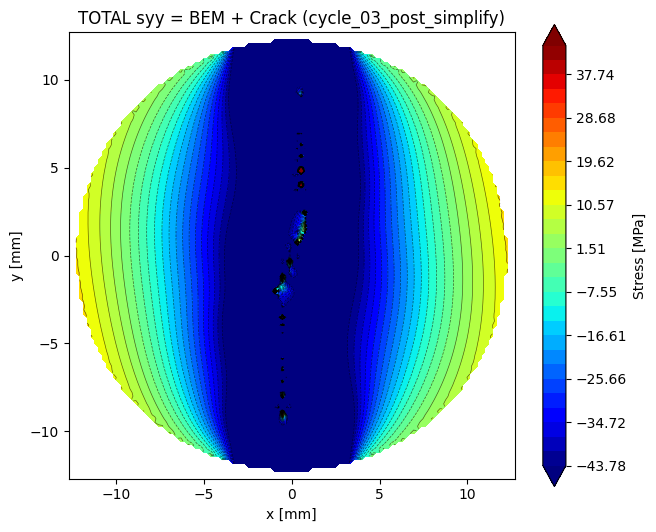

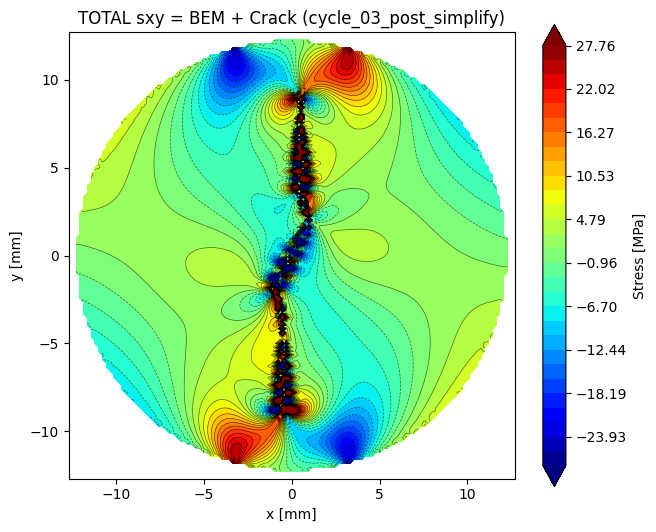

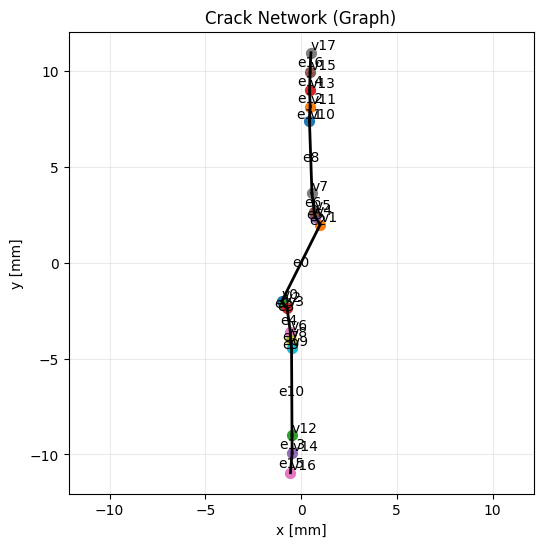

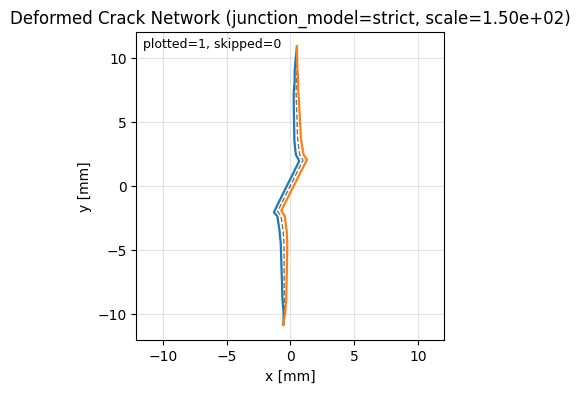

✓ Loaded network: 18 vertices, 17 edges


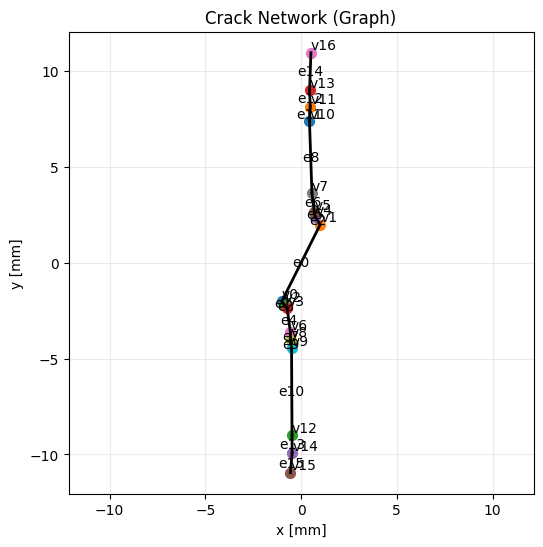

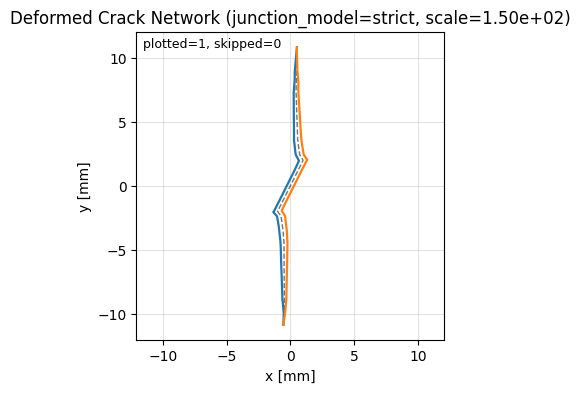

[coupling] UPDATE cycle_04_post_simplify: mismatch=9.479e-02, tip_dist=1.728e-03, tip_thr=2.989e-03, relax=1.00


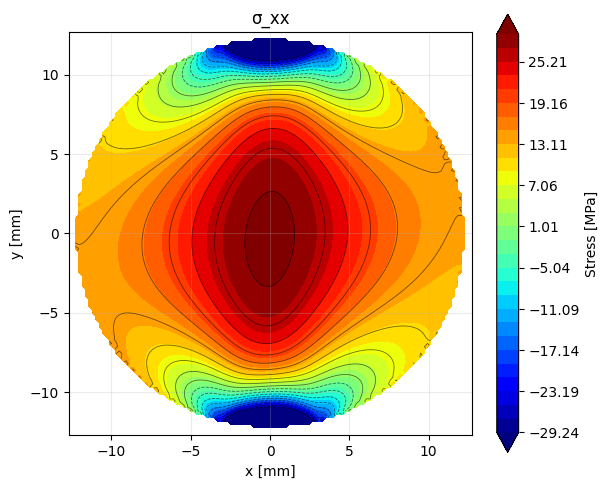

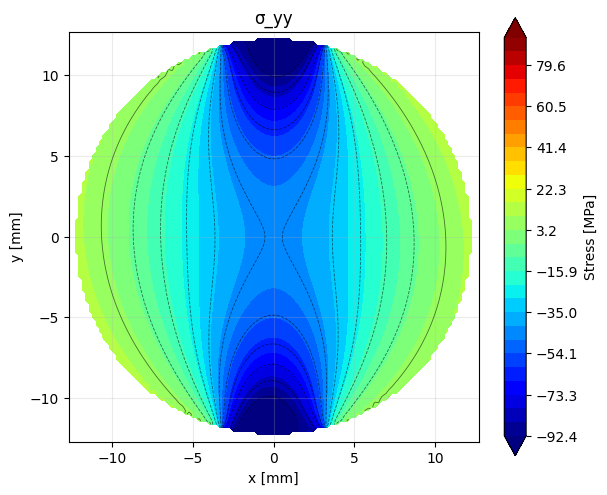

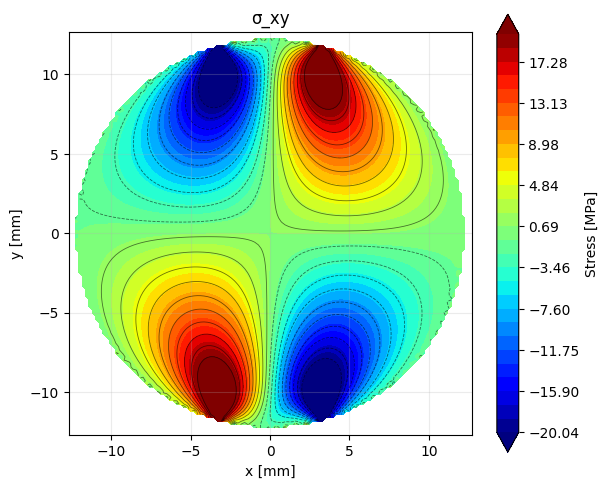

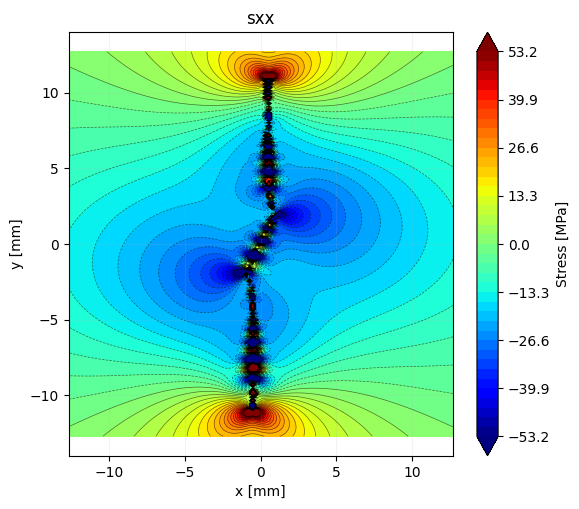

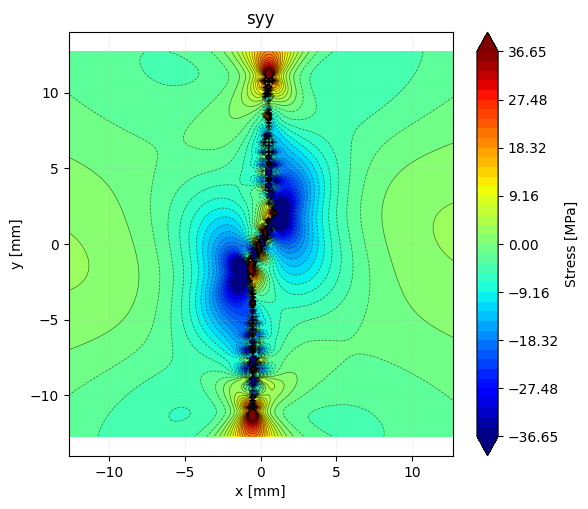

...

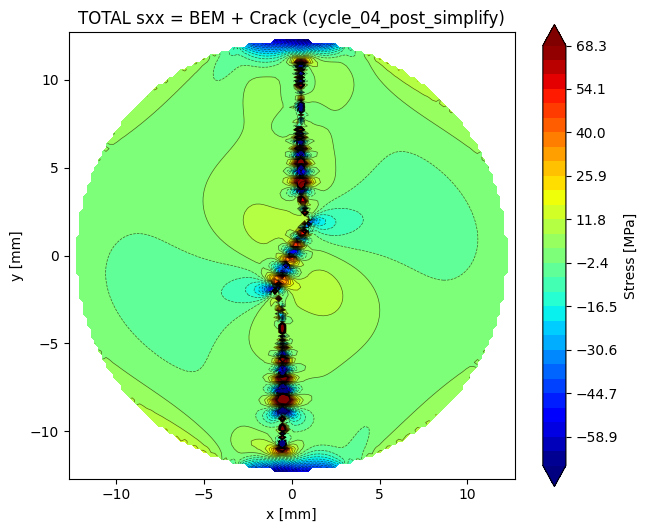

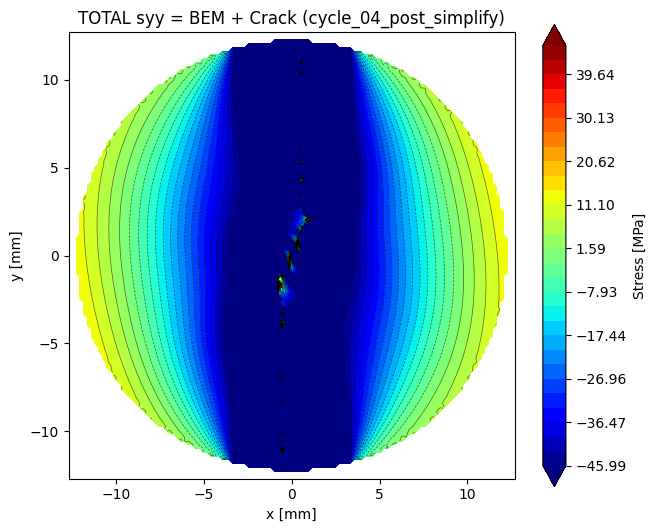

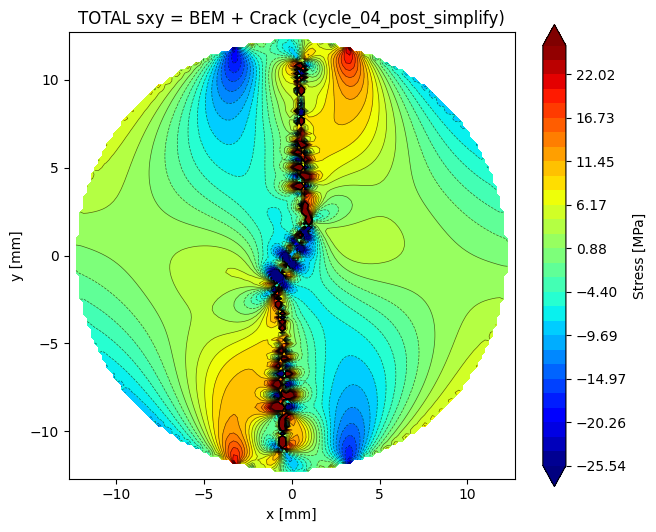

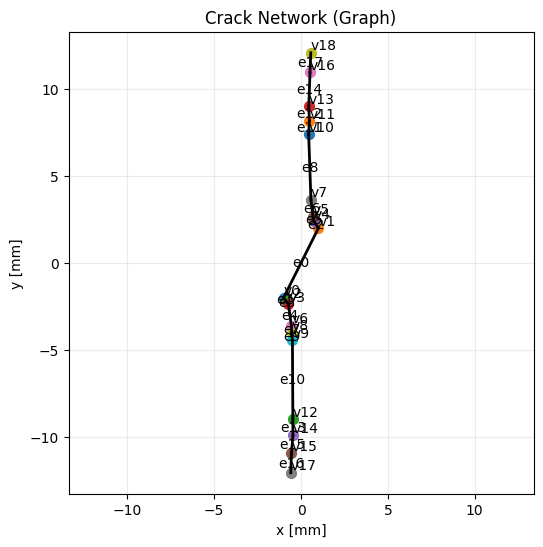

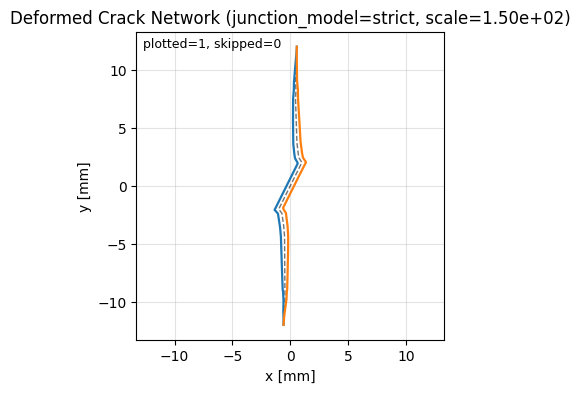

✓ Loaded network: 19 vertices, 18 edges


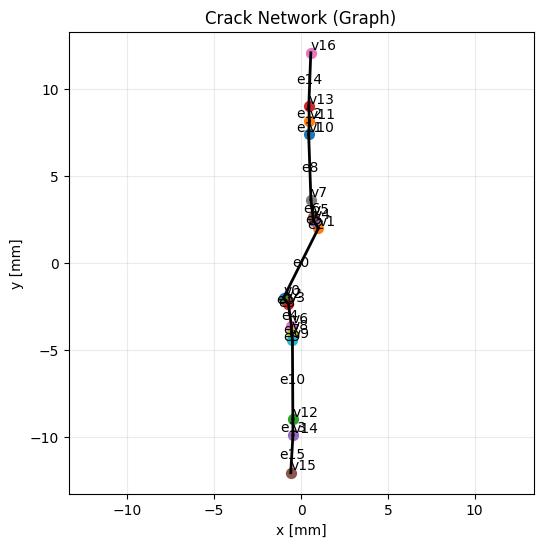

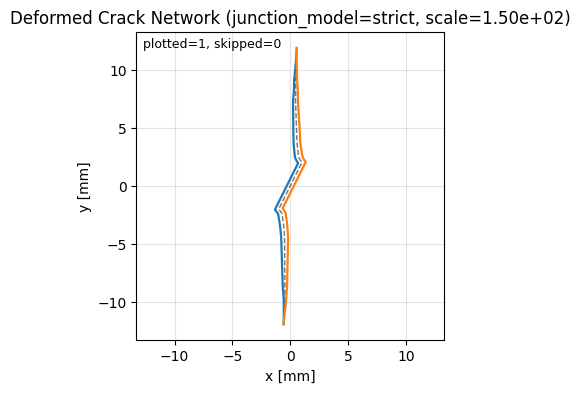

[coupling] UPDATE cycle_05_post_simplify: mismatch=3.253e-02, tip_dist=6.324e-04, tip_thr=5.248e-03, relax=1.00


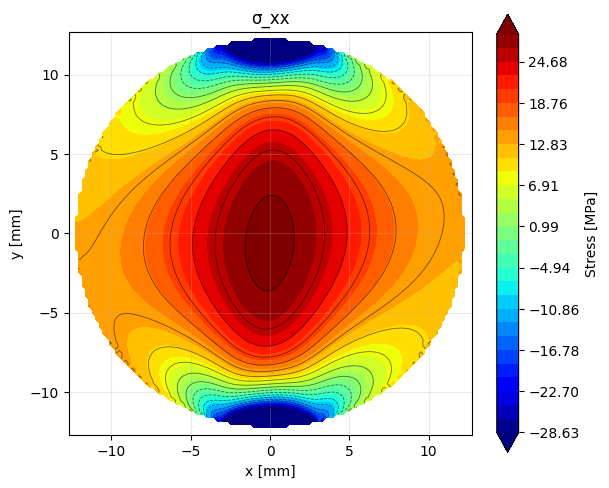

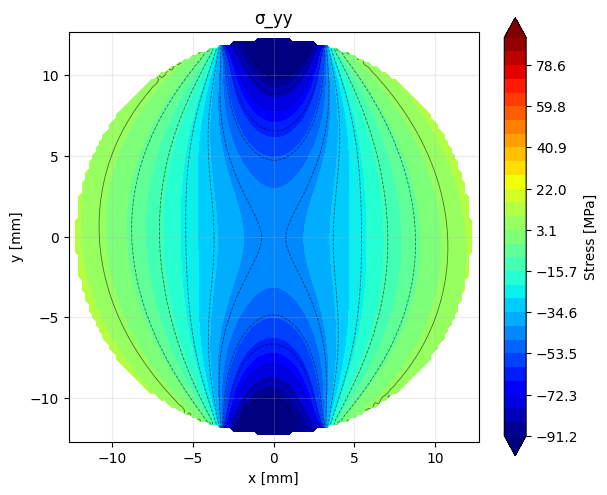

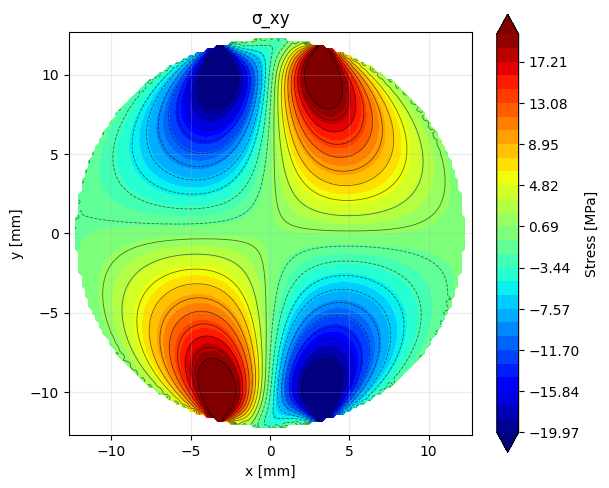

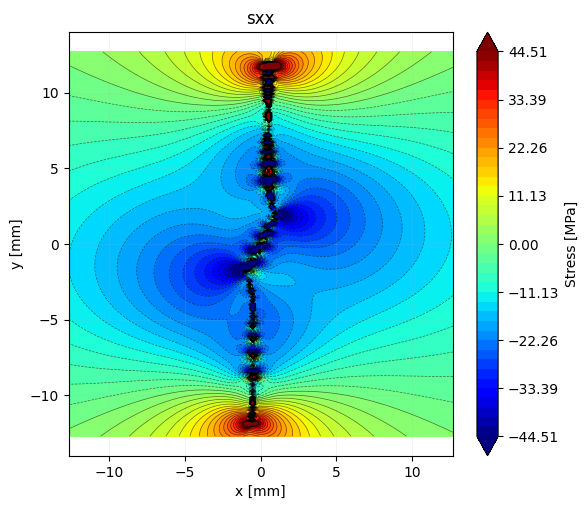

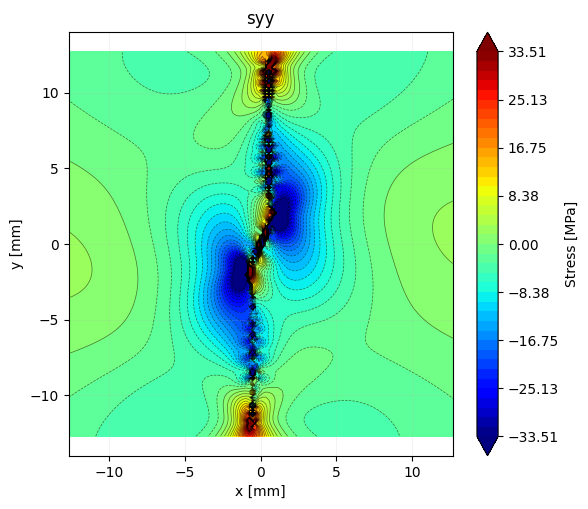

...

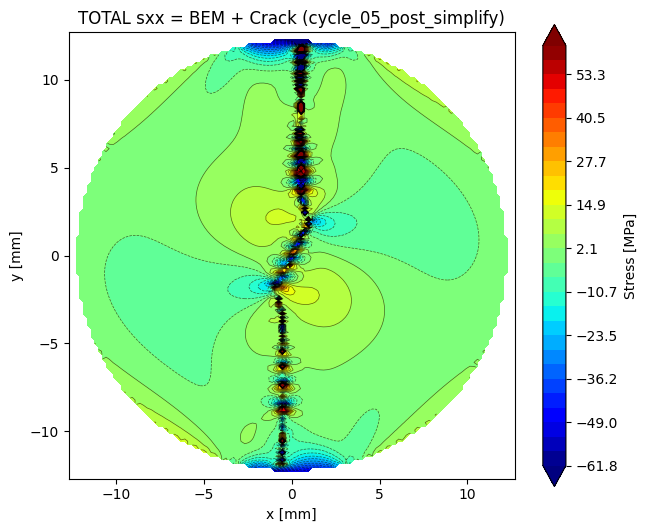

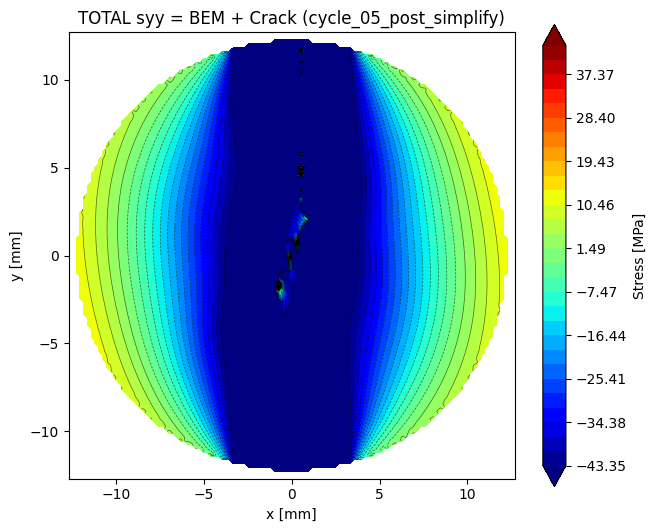

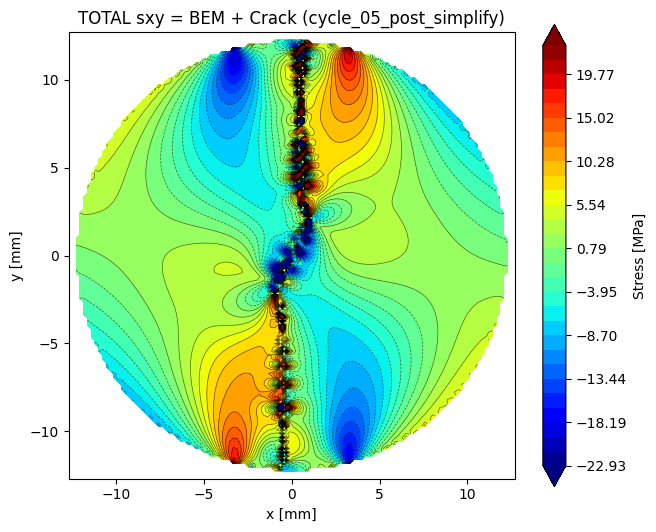

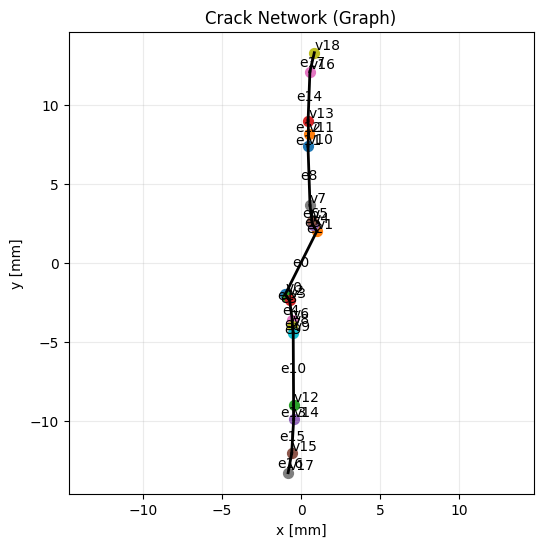

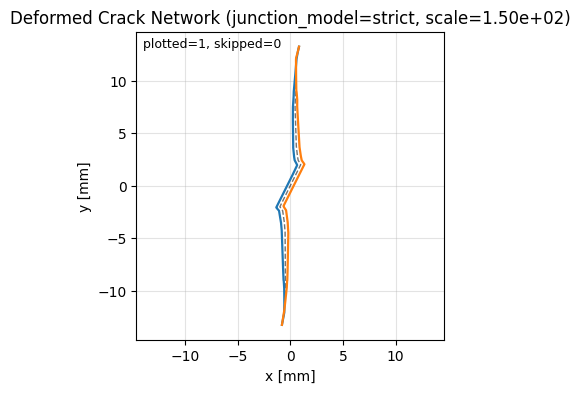

✓ Loaded network: 19 vertices, 18 edges


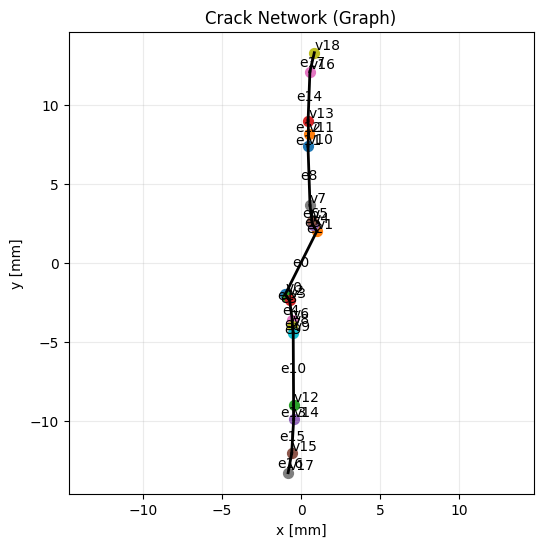

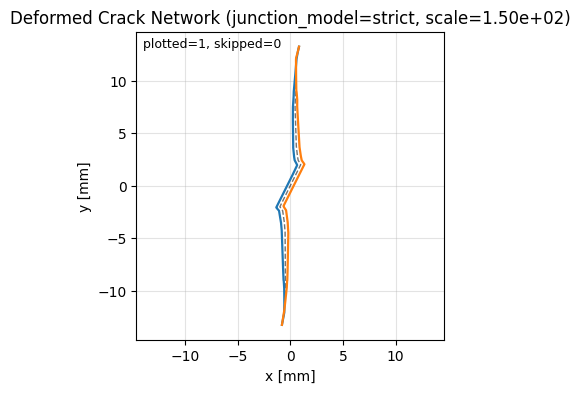

[coupling] UPDATE cycle_06_post_simplify: mismatch=4.484e-02, tip_dist=6.753e-04, tip_thr=2.486e-03, relax=1.00


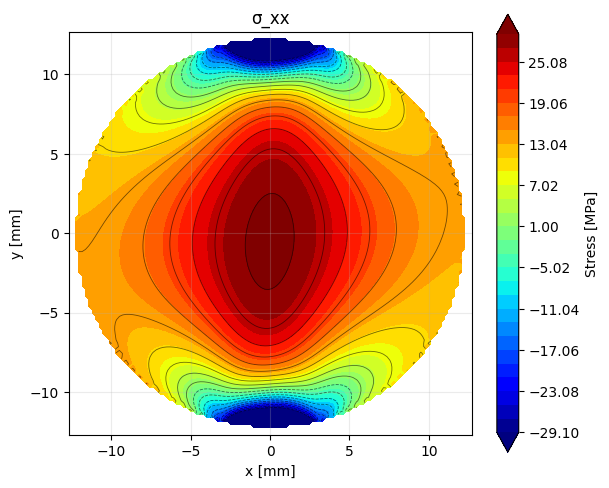

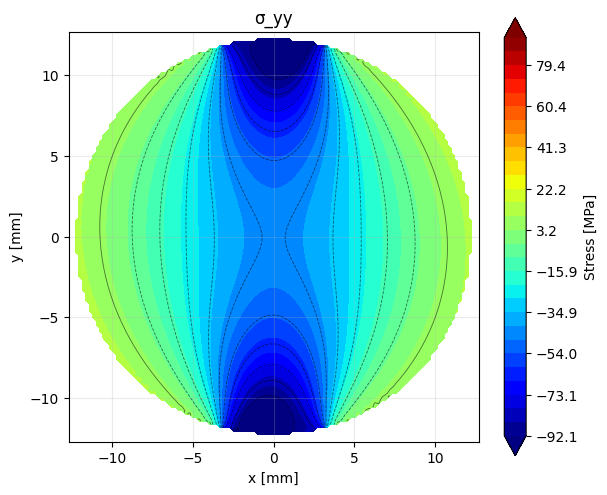

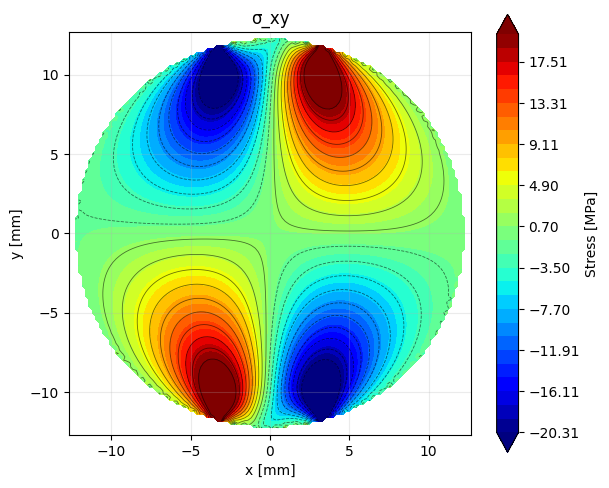

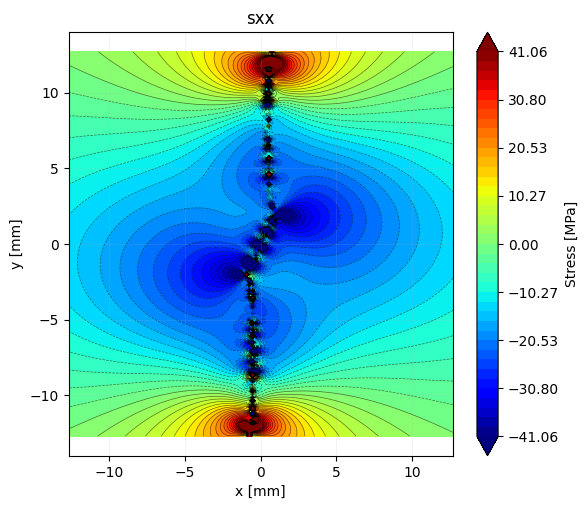

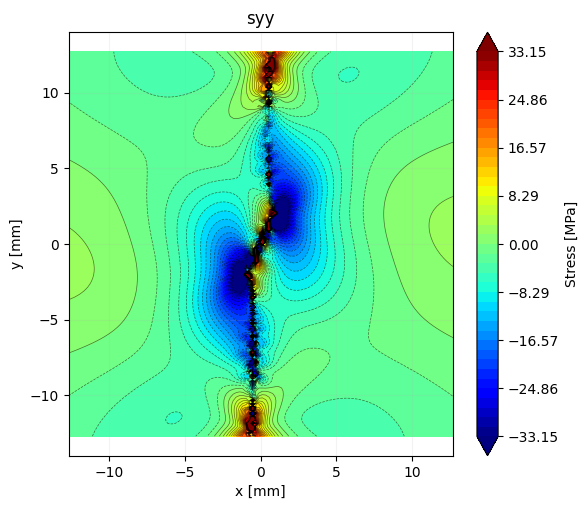

...

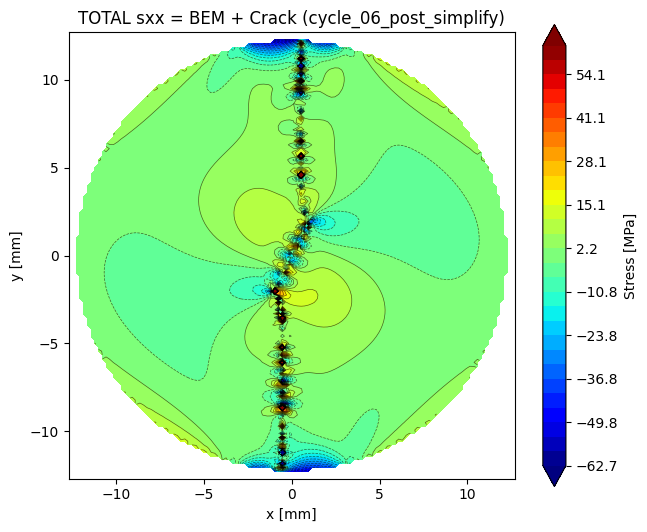

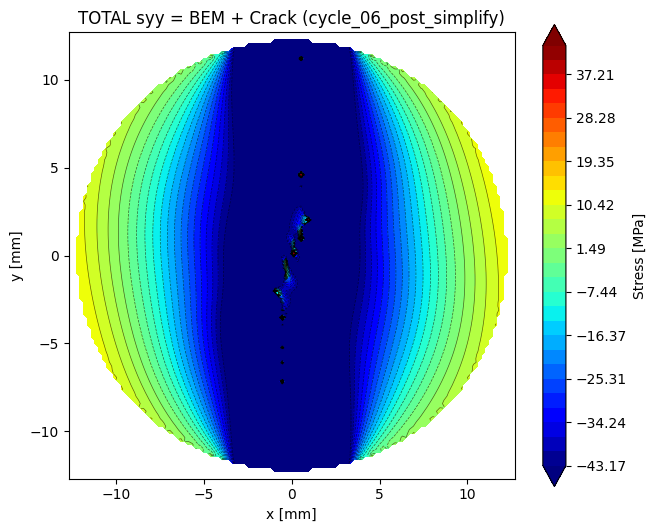

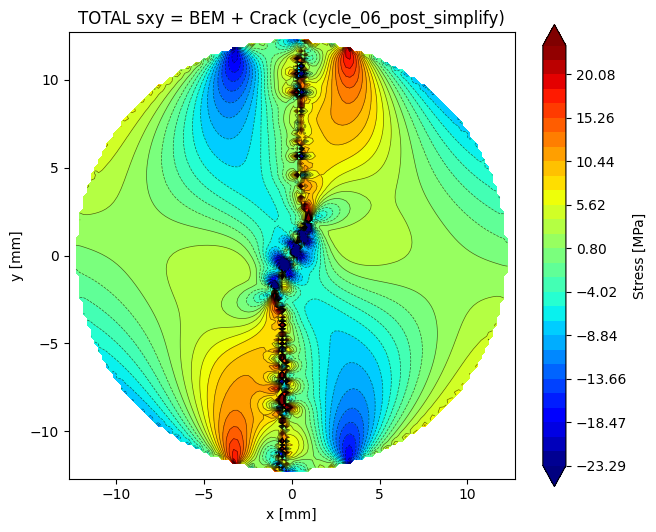

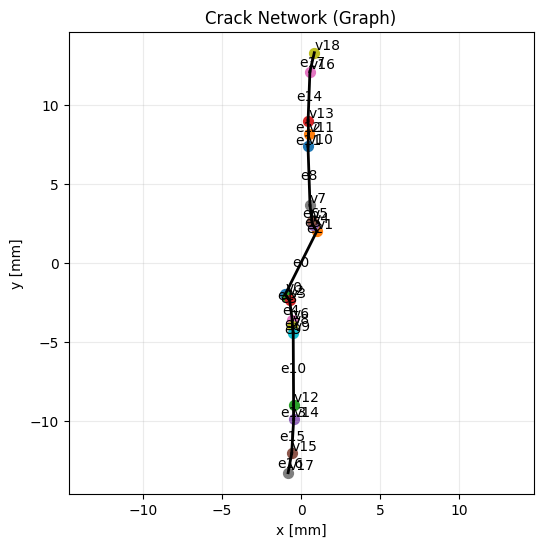

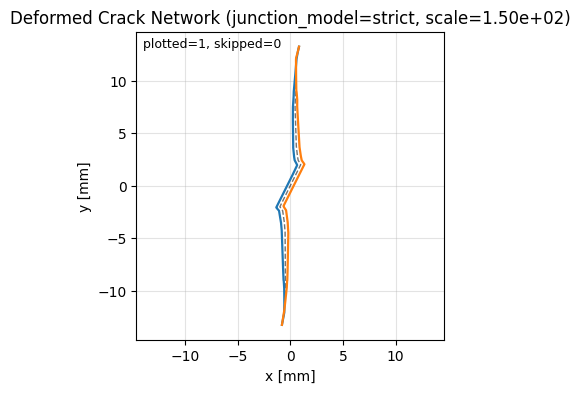

✓ Loaded network: 19 vertices, 18 edges


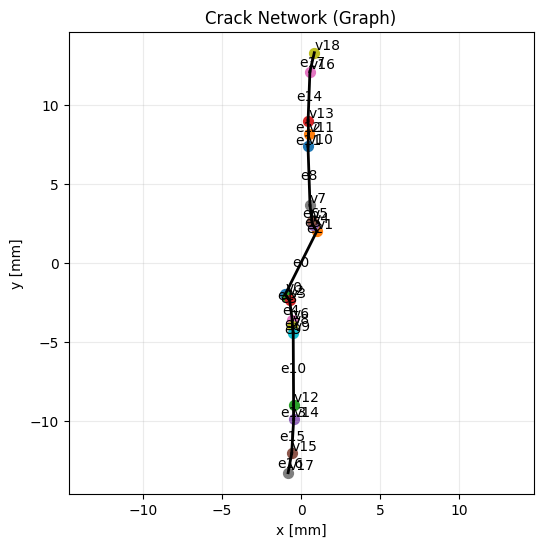

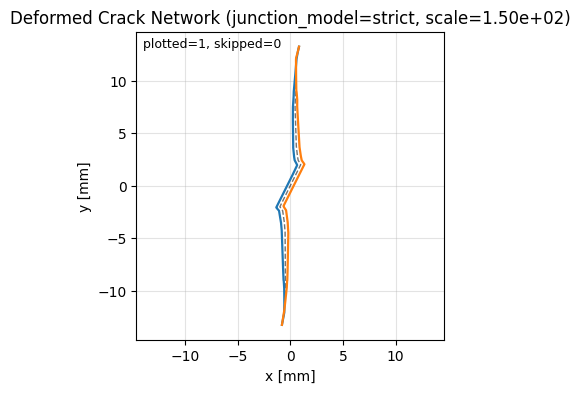

[coupling] UPDATE cycle_07_post_simplify: mismatch=0.000e+00, tip_dist=6.753e-04, tip_thr=2.486e-03, relax=1.00


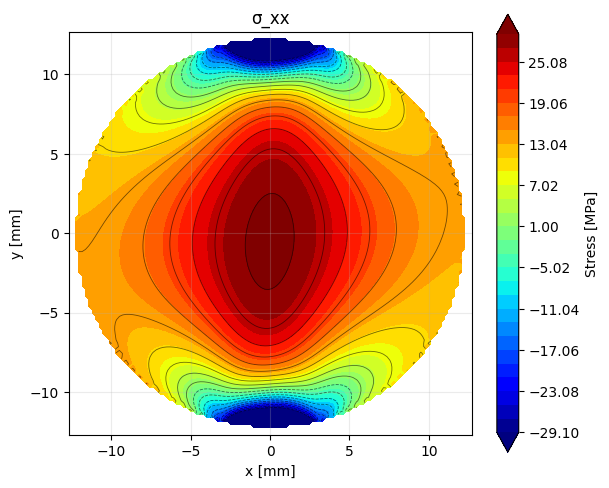

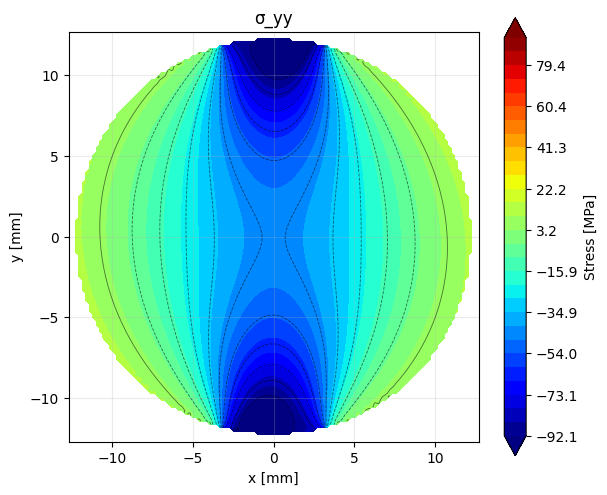

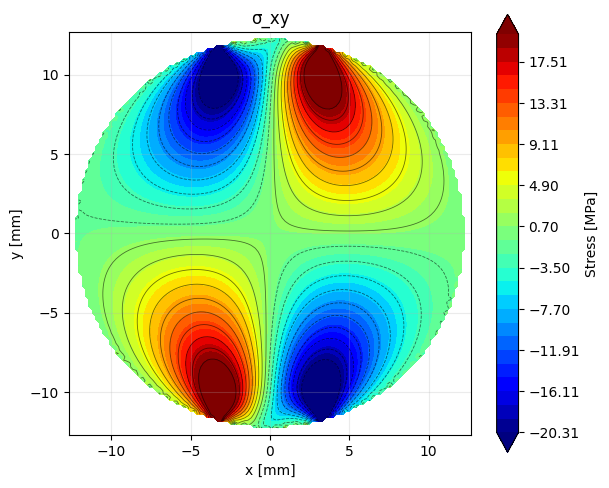

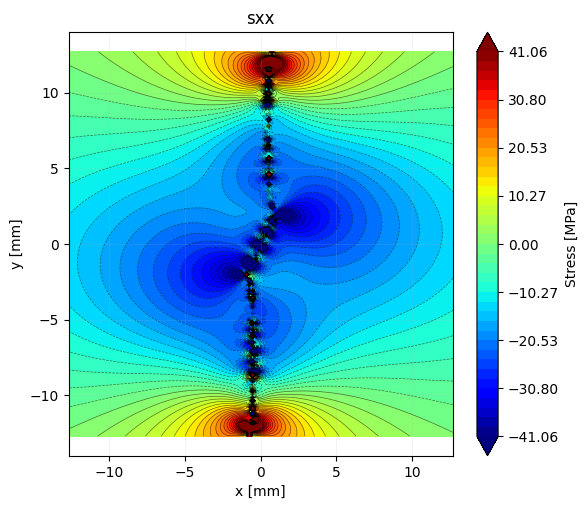

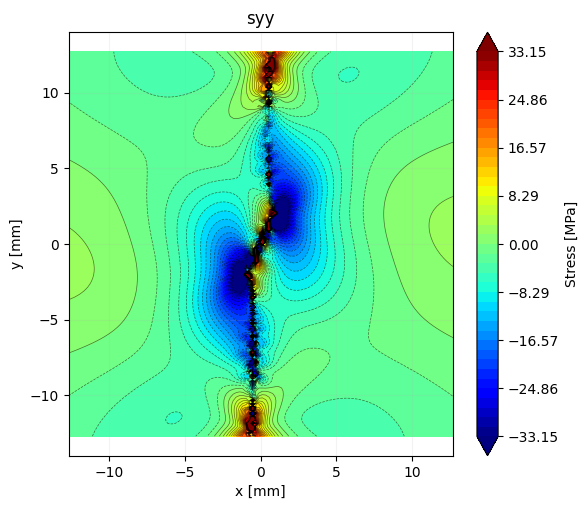

...

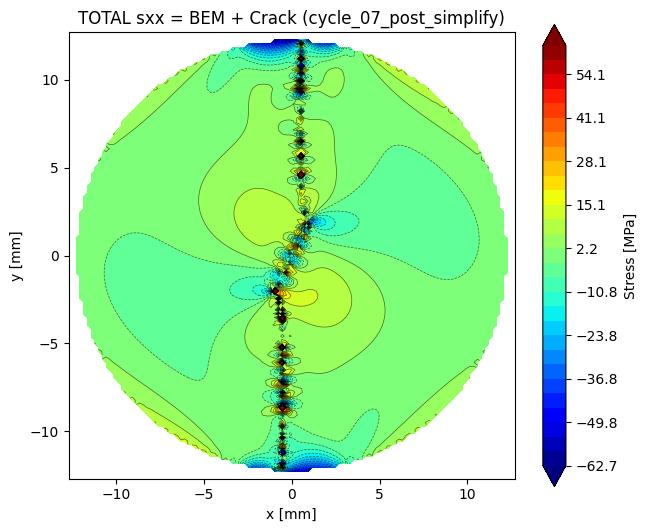

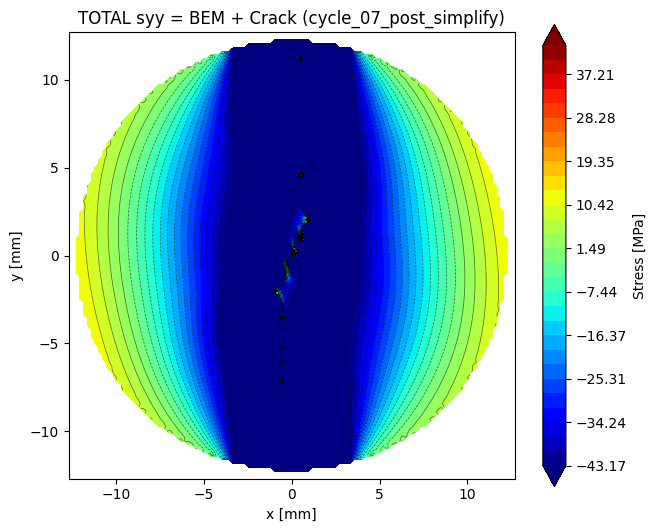

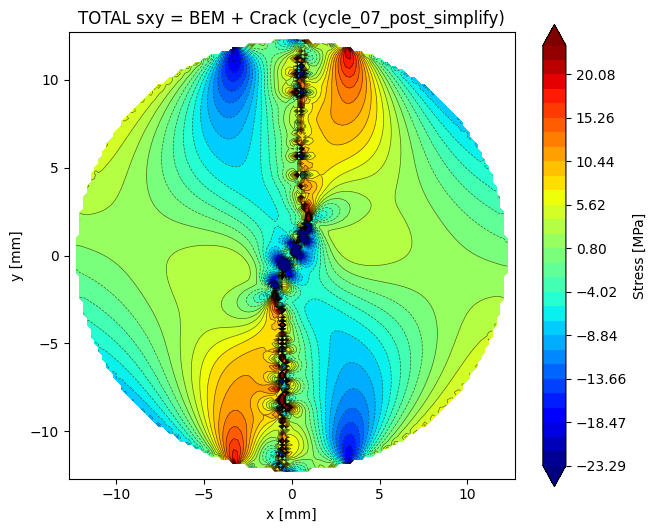

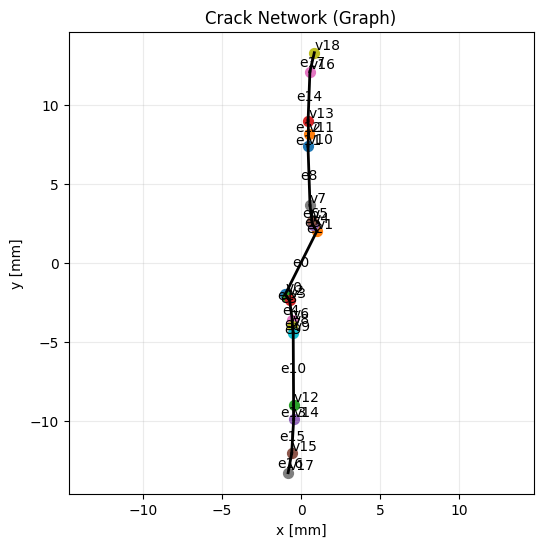

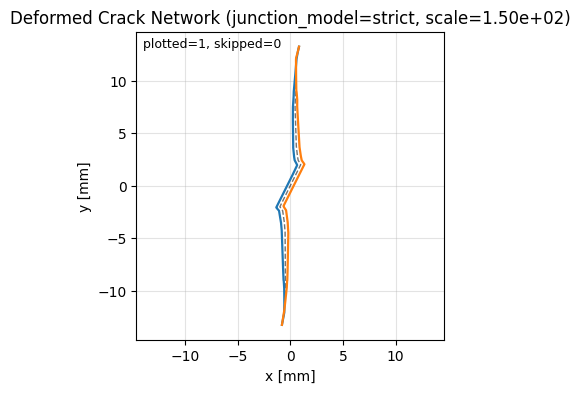

✓ Loaded network: 19 vertices, 18 edges


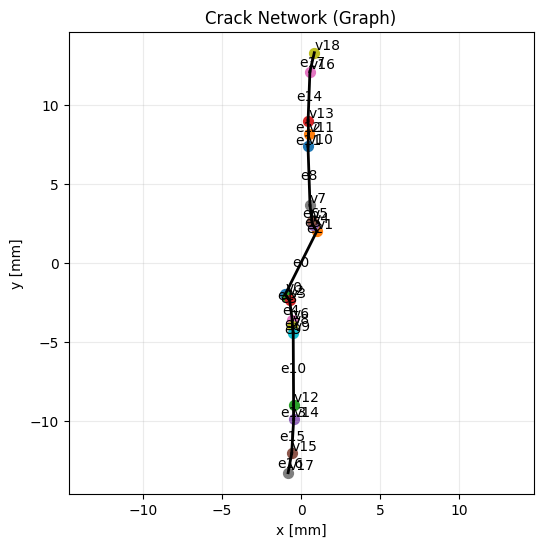

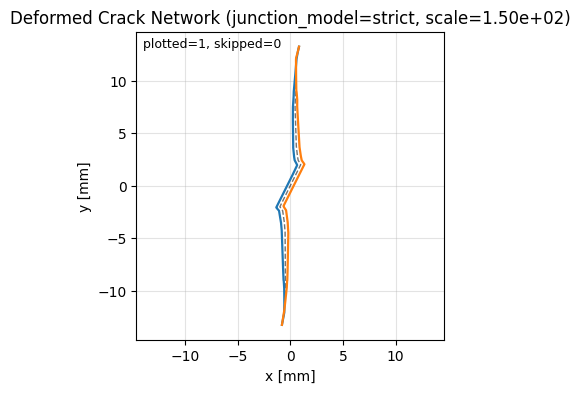

In [ ]:
from pathlib import Path
import os, sys
import numpy as np

# -----------------------
# Repo import path
# -----------------------
nb_dir = Path(os.getcwd()).resolve()
repo_root = nb_dir.parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from fracture_utils.Ubem.brazilian_disk_bem import BrazilianDiskParams, ensure_bem_field
import importlib
from fracture_utils.Ubem import disk_network_propagation as _dnp
_dnp = importlib.reload(_dnp)
CrackGrowthParams = _dnp.CrackGrowthParams
run_network_growth_uncoupled = _dnp.run_network_growth_uncoupled
from fracture_utils.Ubem.disk_crack_plotting import PlotParams, make_standard_plot_hook
from fracture_utils.Ubem import disk_iterative_coupling as _dic

IterativeCouplingParams = _dic.IterativeCouplingParams
compute_crack_boundary_tractions_at_points = getattr(
    _dic,
    "compute_crack_boundary_tractions_at_points",
    _dic.compute_crack_boundary_tractions_via_grid,
)
solve_bem_with_extra_boundary_tractions = _dic.solve_bem_with_extra_boundary_tractions
from fracture_utils.Ubem.boundary_conditions import build_boundary


# -----------------------
# Utility helpers
# -----------------------
def _l2norm2(tx, ty):
    tx = np.asarray(tx, float).reshape(-1)
    ty = np.asarray(ty, float).reshape(-1)
    return float(np.sqrt(np.dot(tx, tx) + np.dot(ty, ty)))


def _cycle_index_from_tag(tag: str):
    parts = str(tag).split("_")
    if len(parts) >= 2 and parts[0] == "cycle":
        try:
            return int(parts[1])
        except Exception:
            return None
    return None


def _vertex_degree_map(network):
    deg = {int(v.id): 0 for v in network.vertices}
    for e in network.edges:
        deg[int(e.v0)] = deg.get(int(e.v0), 0) + 1
        deg[int(e.v1)] = deg.get(int(e.v1), 0) + 1
    return deg


def _tip_points(network):
    deg = _vertex_degree_map(network)
    pts = []
    for v in network.vertices:
        if deg.get(int(v.id), 0) == 1:
            pts.append([float(v.x), float(v.y)])
    if not pts:
        return np.zeros((0, 2), float)
    return np.asarray(pts, float)


def _tip_edge_lengths(network):
    deg = _vertex_degree_map(network)
    edge_by_id = {int(e.id): e for e in network.edges}
    lengths = []

    for v in network.vertices:
        vid = int(v.id)
        if deg.get(vid, 0) != 1 or len(v.edges) == 0:
            continue

        e = edge_by_id.get(int(v.edges[0]))
        if e is None:
            continue

        other = int(e.v1) if int(e.v0) == vid else int(e.v0)
        vo = network.V(other)
        L = float(np.hypot(float(v.x) - float(vo.x), float(v.y) - float(vo.y)))
        if np.isfinite(L) and L > 0:
            lengths.append(L)

    return np.asarray(lengths, float)


def _tip_ids_and_min_boundary_distances(res, boundary_mesh):
    net = getattr(getattr(res, "calc", None), "network", None)
    if net is None:
        return np.zeros((0,), int), np.zeros((0,), float)

    deg = _vertex_degree_map(net)
    tips = []
    tip_ids = []
    for v in net.vertices:
        vid = int(v.id)
        if deg.get(vid, 0) == 1:
            tip_ids.append(vid)
            tips.append([float(v.x), float(v.y)])

    if not tips:
        return np.zeros((0,), int), np.zeros((0,), float)

    tips = np.asarray(tips, float)
    tip_ids = np.asarray(tip_ids, int)

    bxy = np.column_stack([np.asarray(boundary_mesh.xm, float), np.asarray(boundary_mesh.ym, float)])
    d = tips[:, None, :] - bxy[None, :, :]
    dmin = np.min(np.sqrt(np.sum(d * d, axis=2)), axis=1)

    order = np.argsort(tip_ids)
    return tip_ids[order], dmin[order]


def _min_tip_to_boundary_distance(res, boundary_mesh):
    _ids, d = _tip_ids_and_min_boundary_distances(res, boundary_mesh)
    if d.size == 0:
        return np.inf
    return float(np.min(d))


def _characteristic_tip_length(res):
    net = getattr(getattr(res, "calc", None), "network", None)
    if net is None:
        return np.inf
    L = _tip_edge_lengths(net)
    if L.size == 0:
        return np.inf
    return float(np.median(L))


def _disk_external_boundary_tractions(mesh, disk_params):
    """
    External traction BC on the disk boundary (matching solve_bem_with_extra_boundary_tractions):
      - pressure_normal on top arc
      - pressure_normal on bottom arc
      - zero traction elsewhere
    """
    theta_deg = np.asarray(mesh.theta_deg, dtype=float)
    L = np.asarray(mesh.length, dtype=float)

    arc_half = float(getattr(disk_params, "arc_half_angle_deg", 15.0))
    top = (theta_deg >= 90 - arc_half) & (theta_deg <= 90 + arc_half)
    bot = (theta_deg >= -90 - arc_half) & (theta_deg <= -90 + arc_half)

    L_top = float(np.sum(L[top]))
    L_bot = float(np.sum(L[bot]))
    if L_top <= 0 or L_bot <= 0:
        raise RuntimeError("Top/bottom loaded arc has zero length.")

    h = float(getattr(disk_params, "h", 1.0))
    pressure_top = float(disk_params.P_total) / (L_top * h)
    pressure_bot = float(disk_params.P_total) / (L_bot * h)

    tx = np.zeros(mesh.n_seg, float)
    ty = np.zeros(mesh.n_seg, float)

    # pressure_normal => traction = -p * n_out
    tx[top] += -pressure_top * np.asarray(mesh.nx, float)[top]
    ty[top] += -pressure_top * np.asarray(mesh.ny, float)[top]

    tx[bot] += -pressure_bot * np.asarray(mesh.nx, float)[bot]
    ty[bot] += -pressure_bot * np.asarray(mesh.ny, float)[bot]

    return tx, ty


# -----------------------
# Output directory
# -----------------------
bem_dir = repo_root / "output" / "BEM_Brazilian_disk_2"
bem_dir.mkdir(parents=True, exist_ok=True)

# -----------------------
# Network (YOU control)
# -----------------------
mm = 1e-3
vertices = np.array(
    [
        [0,  -1.0 * mm, -2.0 * mm],
        [1,  1.0 * mm,  2.0 * mm],
        # [2,  2.0 * mm, -2.0 * mm],
        # [3, -3.0 * mm,  4.0 * mm],
    ],
    float,
)
connectivity = np.array([[0, 1]], int)

# -----------------------
# (1) BEM (fast reuse option)
# -----------------------
SKIP_BEM_SOLVE = True  # set False to recompute

disk = BrazilianDiskParams(
    R=25.4e-3 / 2,
    P_total=3.8e3,
    E=231.52e9,
    nu=0.3,
    n_elem=120,
    n_grid=120,
    h=6.35e-3,
)

ensure_bem_field(
    disk,
    bem_dir,
    recompute=(not SKIP_BEM_SOLVE),
    show=True,
    save_contours=True,
)

# Build boundary mesh ONCE (used for traction extraction each outer cycle)
boundary_mesh = build_boundary(
    {"type": "circle", "R": disk.R, "n_boundary": disk.n_elem, "center": (0.0, 0.0)}
)

# External traction BC norm (denominator for mismatch indicator)
tx_ext, ty_ext = _disk_external_boundary_tractions(boundary_mesh, disk)
ext_traction_norm = _l2norm2(tx_ext, ty_ext)

# -----------------------
# (2) TOTAL-only plotting controls
# -----------------------
plot_params = PlotParams(
    cmap="jet",
    match_limits_to_crack=True,
    robust=True,
    robust_pct=97.0,
    symmetric=True,
    vmax_factor=2.0,
    n_levels=30,
    n_line_levels=30,
    dpi=300,
)

# Iterative coupling controls
couple = IterativeCouplingParams(
    n_grid=401,
    extent_factor=1.05,
    relax=1.0,  # under-relaxation now applied to extra tractions in this notebook hook
    save_debug_crack_grid=True,
)

# v3.1 occasional-update policy
update_policy = {
    "mismatch_tol": 5.0e-2,  # E_Gamma threshold
    "tip_alpha": 2.0,        # trigger if dist(tip,boundary) < tip_alpha * l_tip
    "min_cycle_gap": 1,      # minimum post_simplify cycles between BEM updates
    "eps": 1.0e-12,
    "tip_stagnation_rel_tol": 0.10,  # stop if ALL tip-boundary distances change by <10%
    "tip_stagnation_method": "moving_avg",  # "moving_avg" or "cycle_to_cycle"
    "tip_stagnation_window_cycles": 3,  # used only for moving_avg
}

hook_total = make_standard_plot_hook(
    bem_dir=bem_dir,
    combined_out_dir=bem_dir,
    plot_params=plot_params,
    show_initial=True,
    show_cycles=True,
    show_final=True,
)

# Mutable coupling state
state = {
    "last_update_cycle": -10**9,
    "tx_cr_last_update": None,
    "ty_cr_last_update": None,
    "tx_extra_last": None,
    "ty_extra_last": None,
    "tip_ids_prev": None,
    "tip_dists_prev": None,
    "tip_history": [],
}


# -----------------------
# Hook: iterative update at end of each OUTER cycle
# -----------------------
def hook(tag, res, step_dir):
    """
    Plot totals always. For post_simplify (end of outer cycle), do:
      crack -> boundary tractions -> (optional) reverse into BEM -> re-solve BEM -> plot totals.

    BEM correction is updated "occasionally" using v3.1-style triggers:
      - boundary mismatch indicator (traction-only here)
      - tip-to-boundary proximity
    """
    step_dir = Path(step_dir)

    if not str(tag).endswith("post_simplify"):
        hook_total(tag, res, step_dir)
        return

    coup_dir = step_dir / "iterative_coupling"
    coup_dir.mkdir(parents=True, exist_ok=True)

    # (1) crack-induced boundary tractions
    tx_cr, ty_cr = compute_crack_boundary_tractions_at_points(
        res=res,
        boundary_mesh=boundary_mesh,
        bem_dir=bem_dir,
        out_dir=coup_dir,
        coupling=couple,
    )

    np.save(coup_dir / f"tx_crack_{tag}.npy", tx_cr)
    np.save(coup_dir / f"ty_crack_{tag}.npy", ty_cr)

    # (2) update policy metrics
    cyc = _cycle_index_from_tag(tag)
    tip_dist = _min_tip_to_boundary_distance(res, boundary_mesh)
    l_tip = _characteristic_tip_length(res)
    tip_threshold = float(update_policy["tip_alpha"]) * l_tip if np.isfinite(l_tip) else np.inf

    tip_ids, tip_dists_all = _tip_ids_and_min_boundary_distances(res, boundary_mesh)
    tip_rel_change_max = np.nan
    tip_stagnation_stop = False

    tol = float(update_policy["tip_stagnation_rel_tol"])
    eps = float(update_policy["eps"])
    method = str(update_policy.get("tip_stagnation_method", "moving_avg")).strip().lower()

    if method == "moving_avg":
        win = max(1, int(update_policy.get("tip_stagnation_window_cycles", 3)))
        hist = list(state.get("tip_history", []))
        compatible = [
            np.asarray(h.get("dists", []), float)
            for h in hist
            if np.array_equal(np.asarray(h.get("ids", []), int), tip_ids)
        ]
        if tip_ids.size > 0 and len(compatible) >= win:
            ref = np.mean(np.stack(compatible[-win:], axis=0), axis=0)
            curr = np.asarray(tip_dists_all, float)
            rel = np.abs(curr - ref) / np.maximum(np.abs(ref), eps)
            tip_rel_change_max = float(np.max(rel)) if rel.size else np.nan
            tip_stagnation_stop = bool(np.all(rel < tol))
    else:
        if (
            state["tip_ids_prev"] is not None
            and state["tip_dists_prev"] is not None
            and tip_ids.size > 0
            and tip_ids.shape == state["tip_ids_prev"].shape
            and np.array_equal(tip_ids, state["tip_ids_prev"])
        ):
            prev = np.asarray(state["tip_dists_prev"], float)
            curr = np.asarray(tip_dists_all, float)
            rel = np.abs(curr - prev) / np.maximum(np.abs(prev), eps)
            tip_rel_change_max = float(np.max(rel)) if rel.size else np.nan
            tip_stagnation_stop = bool(np.all(rel < tol))

    if state["tx_cr_last_update"] is None:
        mismatch = np.inf
    else:
        mismatch = _l2norm2(tx_cr - state["tx_cr_last_update"], ty_cr - state["ty_cr_last_update"]) / (
            ext_traction_norm + float(update_policy["eps"])
        )

    mismatch_trigger = bool(mismatch > float(update_policy["mismatch_tol"]))
    tip_trigger = bool(np.isfinite(tip_dist) and np.isfinite(tip_threshold) and (tip_dist < tip_threshold))

    if cyc is None:
        gap_ok = True
    else:
        gap_ok = (int(cyc) - int(state["last_update_cycle"])) >= int(update_policy["min_cycle_gap"])

    first_update = state["tx_cr_last_update"] is None
    do_update = bool(first_update or (gap_ok and (mismatch_trigger or tip_trigger)))

    if do_update:
        # target correction: reverse crack tractions
        tx_target = -np.asarray(tx_cr, float)
        ty_target = -np.asarray(ty_cr, float)

        relax = float(np.clip(couple.relax, 0.0, 1.0))
        if state["tx_extra_last"] is None:
            tx_extra = tx_target
            ty_extra = ty_target
        else:
            tx_extra = (1.0 - relax) * state["tx_extra_last"] + relax * tx_target
            ty_extra = (1.0 - relax) * state["ty_extra_last"] + relax * ty_target

        solve_bem_with_extra_boundary_tractions(
            disk_params=disk,
            bem_dir=bem_dir,
            tx_extra=tx_extra,
            ty_extra=ty_extra,
            show=False,
        )

        state["last_update_cycle"] = int(cyc) if cyc is not None else state["last_update_cycle"]
        state["tx_cr_last_update"] = np.asarray(tx_cr, float).copy()
        state["ty_cr_last_update"] = np.asarray(ty_cr, float).copy()
        state["tx_extra_last"] = np.asarray(tx_extra, float).copy()
        state["ty_extra_last"] = np.asarray(ty_extra, float).copy()

        print(
            f"[coupling] UPDATE {tag}: "
            f"mismatch={mismatch:.3e}, tip_dist={tip_dist:.3e}, "
            f"tip_thr={tip_threshold:.3e}, relax={relax:.2f}"
        )
    else:
        print(
            f"[coupling] SKIP   {tag}: "
            f"mismatch={mismatch:.3e}, tip_dist={tip_dist:.3e}, "
            f"tip_thr={tip_threshold:.3e}, gap_ok={gap_ok}"
        )

    state["tip_ids_prev"] = np.asarray(tip_ids, int).copy()
    state["tip_dists_prev"] = np.asarray(tip_dists_all, float).copy()
    state["tip_history"].append({"ids": np.asarray(tip_ids, int).copy(), "dists": np.asarray(tip_dists_all, float).copy()})
    if len(state["tip_history"]) > 20:
        state["tip_history"] = state["tip_history"][-20:]

    np.savez(
        coup_dir / f"policy_metrics_{tag}.npz",
        mismatch=np.array([mismatch], float),
        mismatch_tol=np.array([float(update_policy["mismatch_tol"])], float),
        tip_dist=np.array([tip_dist], float),
        tip_threshold=np.array([tip_threshold], float),
        l_tip=np.array([l_tip], float),
        gap_ok=np.array([float(gap_ok)], float),
        do_update=np.array([float(do_update)], float),
        ext_traction_norm=np.array([ext_traction_norm], float),
        n_tips=np.array([float(tip_ids.size)], float),
        tip_rel_change_max=np.array([tip_rel_change_max], float),
        tip_stagnation_stop=np.array([float(tip_stagnation_stop)], float),
        tip_stagnation_method=np.array([0.0 if method == "moving_avg" else 1.0], float),
        tip_stagnation_window_cycles=np.array([float(update_policy.get("tip_stagnation_window_cycles", 3))], float),
    )

    # (3) plot totals with current BEM arrays (updated or held)
    hook_total(tag, res, step_dir)

    if tip_stagnation_stop:
        print(
            f"[coupling] STOP   {tag}: all tip-boundary distances changed by <"
            f" {100.0*float(update_policy['tip_stagnation_rel_tol']):.1f}%"
            f" using method={method}"
        )
        return {"stop": True, "reason": "tip_boundary_stagnation", "cycle": cyc}


# -----------------------
# Growth params + run
# -----------------------
grow = CrackGrowthParams(
    max_cycles=10,
    L_limit_mm=20.0,
    vertex_high=18,
    deformed_plot_scale=150,
)

res_final = run_network_growth_uncoupled(
    bem_dir=bem_dir,
    out_dir=bem_dir,
    vertices=vertices,
    connectivity=connectivity,
    params=grow,
    plot_hook=hook,
)

